
# EXIOBASE 3.9.6 terrestrial animal-product consumption-based emissions  
## Reproducible analysis notebook

This notebook runs the EXIOBASE consumption-based emissions analysis. It reads the raw EXIOBASE `IOT_2020_ixi.zip`, `IOT_2021_ixi.zip`, `IOT_2022_ixi.zip` files and World Bank population data, then generates:

- manuscript figures for **terrestrial animal products**;
- country/region-level total and per-capita emissions;
- top contributor plots and tables;
- population-context plots used for manuscript interpretation;
- sector audit tables;
- sector-boundary sensitivity outputs.

### Required input files

Place these files in a local `data/` directory beside this notebook:

```text
data/
├── IOT_2020_ixi.zip
├── IOT_2021_ixi.zip
├── IOT_2022_ixi.zip
└── API_SP.POP.TOTL_...zip  # World Bank WDI population download
```

The notebook writes outputs to:

```text
outputs/ and figures/
```


In [1]:

from __future__ import annotations

import io
import zipfile
import csv
import glob
import warnings
from pathlib import Path
from typing import List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path("data")
OUT_DIR = Path("outputs")
FIG_DIR = Path("figures")

for directory in [DATA_DIR, OUT_DIR, FIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

YEARS = [2020, 2021, 2022]

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "figure.dpi": 300,
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.titlepad": 10,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.30,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "legend.frameon": False,
})

print("Data directory:", DATA_DIR.resolve())
print("Output directory:", OUT_DIR.resolve())
print("Figure directory:", FIG_DIR.resolve())


Data directory: /Users/ritukajaiswal/Desktop/Climate Change Book/Animal Farming Paper/plots/Final Plots for livestock emissions/Review report JCLP/github_ready_code_files/exiobase/data
Output directory: /Users/ritukajaiswal/Desktop/Climate Change Book/Animal Farming Paper/plots/Final Plots for livestock emissions/Review report JCLP/github_ready_code_files/exiobase/outputs
Figure directory: /Users/ritukajaiswal/Desktop/Climate Change Book/Animal Farming Paper/plots/Final Plots for livestock emissions/Review report JCLP/github_ready_code_files/exiobase/figures



## 1. Regional groups and population mapping

The study reports results for Global North (GN), China (CN), and Global South excluding China (GS).
Country-level outputs use EXIOBASE destination regions. EXIOBASE aggregate Rest-of-World regions are excluded from per-capita calculations because they do not map cleanly to World Bank population values.


In [2]:

GN_ISO2 = {
    "AT","BE","BG","CY","CZ","DE","DK","EE","ES","FI","FR","GR","HR","HU","IE","IT",
    "LT","LU","LV","MT","NL","PL","PT","RO","SE","SI","SK","GB","NO","CH","IS",
    "US","CA","AU","NZ","JP","KR","TW"
}

def which_group(iso2: str) -> str:
    if iso2 == "CN":
        return "CN"
    return "GN" if iso2 in GN_ISO2 else "GS"

MAP_EXIO_TO_WB = {
    "AT":"Austria","BE":"Belgium","BG":"Bulgaria","CY":"Cyprus","CZ":"Czechia",
    "DE":"Germany","DK":"Denmark","EE":"Estonia","ES":"Spain","FI":"Finland",
    "FR":"France","GR":"Greece","HR":"Croatia","HU":"Hungary","IE":"Ireland",
    "IT":"Italy","LT":"Lithuania","LU":"Luxembourg","LV":"Latvia","MT":"Malta",
    "NL":"Netherlands","PL":"Poland","PT":"Portugal","RO":"Romania","SE":"Sweden",
    "SI":"Slovenia","SK":"Slovak Republic","GB":"United Kingdom","NO":"Norway",
    "CH":"Switzerland","IS":"Iceland","US":"United States","CA":"Canada",
    "AU":"Australia","NZ":"New Zealand","JP":"Japan","KR":"Korea, Rep.",
    "TW":"Taiwan, China","BR":"Brazil","IN":"India","MX":"Mexico",
    "RU":"Russian Federation","TR":"Türkiye","ID":"Indonesia","ZA":"South Africa",
    "CN":"China"
}

def pretty_country(iso2: str) -> str:
    return MAP_EXIO_TO_WB.get(iso2, iso2)

GROUP_LABELS = {
    "GN": "Global North",
    "CN": "China",
    "GS": "Global South (ex-China)"
}

GROUP_ORDER = ["GN", "CN", "GS"]



## 2. Sector definitions

The revised main analysis excludes fisheries and aquaculture to maintain consistency with the terrestrial land-use-change framework.

Two additional sensitivity scopes are included:
1. `core_livestock_meat_dairy` — excludes broad “Animal products” sector;
2. `old_scope_including_fish` — reproduces the broader original boundary for comparison only.


In [3]:

CORE_LIVESTOCK_KEYWORDS = [
    "Cattle farming",
    "Pigs farming",
    "Poultry farming",
    "Meat animals",
    "Raw milk",
    "Processing of meat",
    "Production of meat products",
    "Processing of dairy",
]

TERRESTRIAL_ANIMAL_KEYWORDS = CORE_LIVESTOCK_KEYWORDS + [
    "Animal products",  # captures eggs/other terrestrial animal products where EXIOBASE aggregates them
]

OLD_SCOPE_INCLUDING_FISH_KEYWORDS = TERRESTRIAL_ANIMAL_KEYWORDS + [
    "Manufacture of fish products",
    "Fishing",
]

EXCLUDE_FISH_KEYWORDS = [
    "fish",
    "fishing",
    "aquaculture",
]

SECTOR_SCOPES = {
    "terrestrial_animal_products": {
        "include": TERRESTRIAL_ANIMAL_KEYWORDS,
        "exclude": EXCLUDE_FISH_KEYWORDS,
        "description": "Main revised scope: meat, dairy, eggs/other terrestrial animal products; excludes fisheries/aquaculture."
    },
    "core_livestock_meat_dairy": {
        "include": CORE_LIVESTOCK_KEYWORDS,
        "exclude": EXCLUDE_FISH_KEYWORDS,
        "description": "Sensitivity: core livestock/meat/dairy sectors, excluding broad Animal products sector."
    },
    "old_scope_including_fish": {
        "include": OLD_SCOPE_INCLUDING_FISH_KEYWORDS,
        "exclude": [],
        "description": "Sensitivity: broad original scope including fisheries/fish products."
    },
}

def sector_matches(sector_name: str, include_keywords: List[str], exclude_keywords: List[str]) -> bool:
    s = str(sector_name).lower()
    include = any(k.lower() in s for k in include_keywords)
    exclude = any(k.lower() in s for k in exclude_keywords)
    return include and not exclude

def selected_sector_mask(index: pd.MultiIndex, scope_name: str) -> pd.Series:
    cfg = SECTOR_SCOPES[scope_name]
    sectors = index.get_level_values("origin_sector").to_series()
    return sectors.apply(lambda s: sector_matches(s, cfg["include"], cfg["exclude"])).astype(bool)

print("Sector scopes:")
for k, v in SECTOR_SCOPES.items():
    print(f"- {k}: {v['description']}")


Sector scopes:
- terrestrial_animal_products: Main revised scope: meat, dairy, eggs/other terrestrial animal products; excludes fisheries/aquaculture.
- core_livestock_meat_dairy: Sensitivity: core livestock/meat/dairy sectors, excluding broad Animal products sector.
- old_scope_including_fish: Sensitivity: broad original scope including fisheries/fish products.


## 3. Utility functions

In [4]:

def _sniff_delim(sample_text: str, fallback: str = ",") -> str:
    try:
        return csv.Sniffer().sniff(sample_text).delimiter
    except Exception:
        if sample_text.count("\t") >= max(sample_text.count(","), sample_text.count(";")):
            return "\t"
        if sample_text.count(";") >= sample_text.count(","):
            return ";"
        return fallback

def find_wb_pop_file(data_dir: Path = Path("data")) -> Path:
    patterns = [
        "API_SP.POP.TOTL_DS2_*.zip",
        "API_SP.POP.TOTL_*.zip",
        "*SP.POP.TOTL*.zip",
        "*POP*TOTL*.zip",
        "API_SP.POP.TOTL_DS2_*.csv",
        "API_SP.POP.TOTL_*.csv",
        "*SP.POP.TOTL*.csv",
        "*POP*TOTL*.csv",
    ]
    for pat in patterns:
        hits = sorted(Path(p) for p in glob.glob(str(data_dir / pat)))
        if hits:
            return hits[-1]
    raise FileNotFoundError("World Bank population file not found in ./data/.")

def _find_member(names, patterns):
    pats = [p.lower() for p in patterns]
    for n in names:
        s = n.lower()
        if all(p in s for p in pats):
            return n
    return None


## 4. Load EXIOBASE matrices

In [5]:

def load_exio(exio_zip: Path):
    # Read A, Y, x, and F from an EXIOBASE ixi zip.
    with zipfile.ZipFile(exio_zip, "r") as z:
        names = z.namelist()

        A_name = _find_member(names, ["a.txt"])
        Y_name = _find_member(names, ["y.txt"])
        x_name = _find_member(names, ["x.txt"]) or _find_member(names, ["indout"])

        if not (A_name and Y_name and x_name):
            raise FileNotFoundError(f"Missing A/Y/x in EXIO zip: {exio_zip}")

        A = pd.read_csv(z.open(A_name), sep="\t", header=[0,1], index_col=[0,1], low_memory=False)
        Y = pd.read_csv(z.open(Y_name), sep="\t", header=[0,1], index_col=[0,1], low_memory=False)

        A.index.names = ["supplier_region", "supplier_sector"]
        A.columns.names = ["buyer_region", "buyer_sector"]
        Y.index.names = ["origin_region", "origin_sector"]
        Y.columns.names = ["dest_region", "category"]

        raw_x = z.read(x_name).decode("utf-8", errors="ignore")
        delim_x = _sniff_delim("\n".join(raw_x.splitlines()[:5]))
        x_df = pd.read_csv(io.StringIO(raw_x), sep=delim_x, low_memory=False)

        ren = {}
        for c in x_df.columns:
            lc = str(c).lower().strip()
            if lc in ("region", "country", "area"):
                ren[c] = "region"
            elif lc in ("sector", "industry", "product"):
                ren[c] = "sector"
            elif lc.startswith("indout") or lc in ("output", "total output", "x"):
                ren[c] = "indout"

        x_df = x_df.rename(columns=ren)
        if not {"region", "sector", "indout"}.issubset(x_df.columns):
            raise ValueError(f"x columns not recognized: {x_df.columns.tolist()}")

        x_df = x_df[["region", "sector", "indout"]]

        candidates = [
            n for n in names
            if ("air" in n.lower() or "emiss" in n.lower())
            and n.lower().endswith(".txt")
            and "unit" not in n.lower()
        ]

        if not candidates:
            raise FileNotFoundError("No air/emissions .txt found in EXIO zip.")

        best = None
        for n in candidates:
            raw = z.read(n).decode("utf-8", errors="ignore")
            line = next((l for l in raw.splitlines() if l.strip()), "")
            delimF = "\t" if line.count("\t") >= max(line.count(","), line.count(";")) else (
                "," if line.count(",") >= line.count(";") else ";"
            )
            cols = line.count(delimF) + 1
            if best is None or cols > best[0]:
                best = (cols, delimF, n, raw)

        _, delimF, F_name, raw_F = best
        F_raw = pd.read_csv(io.StringIO(raw_F), sep=delimF, header=0, low_memory=False)
        F_raw = F_raw.rename(columns={F_raw.columns[0]: "pollutant"}).set_index("pollutant")

    N = len(A.columns)
    if F_raw.shape[1] < N:
        raise ValueError("Emissions table has fewer columns than A.")

    F = F_raw.iloc[:, :N].copy()
    F.columns = pd.MultiIndex.from_tuples(list(A.columns))
    F = F.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    return A, Y, x_df, F


## 5. Emissions intensity and MRIO accounting

In [6]:

def sum_pollutant(F: pd.DataFrame, include_terms: List[str]) -> Optional[pd.Series]:
    inc = [t.lower() for t in include_terms]
    selected = []
    for r in F.index:
        name = str(r).lower()
        if all(t in name for t in inc):
            selected.append(r)
    if not selected:
        return None
    return F.loc[selected].astype(float).sum(axis=0)

def build_co2e_intensity(A: pd.DataFrame, x_df: pd.DataFrame, F: pd.DataFrame) -> pd.Series:
    # Return emissions intensity s in t CO2e per EUR, aligned to A columns.
    # Uses AR6 GWP100: CH4 = 27.2, N2O = 273.
    co2 = sum_pollutant(F, ["co2"])
    ch4 = sum_pollutant(F, ["ch4"])
    n2o = sum_pollutant(F, ["n2o"])

    if co2 is None or ch4 is None or n2o is None:
        raise ValueError("Could not identify CO2, CH4, and N2O rows in environmental satellite accounts.")

    CO2e_t = (co2 + 27.2 * ch4 + 273.0 * n2o) / 1000.0

    x_wide = x_df.pivot_table(index="region", columns="sector", values="indout", aggfunc="first")

    x_vec = []
    for rg, sec in zip(A.columns.get_level_values(0), A.columns.get_level_values(1)):
        try:
            x_vec.append(float(x_wide.loc[rg, sec]))
        except Exception:
            x_vec.append(np.nan)

    x_vec = pd.Series(x_vec, index=A.columns, dtype=float)
    s = (CO2e_t / x_vec).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return s

def filter_consumption_Y(Y: pd.DataFrame, include_gov: bool = True) -> pd.DataFrame:
    keep = ["Final consumption expenditure by households"]
    if include_gov:
        keep += [
            "Final consumption expenditure by non-profit organisations serving households",
            "Final consumption expenditure by government",
        ]

    mask = Y.columns.get_level_values("category").isin(keep)
    Y_keep = Y.loc[:, mask]
    return Y_keep.T.groupby(level="dest_region").sum().T

def filter_scope_rows(Y_demand: pd.DataFrame, scope_name: str) -> pd.DataFrame:
    mask = selected_sector_mask(Y_demand.index, scope_name)
    Y_scope = Y_demand.copy()
    Y_scope.loc[~mask.values, :] = 0.0
    return Y_scope

def audit_retained_sectors(Y_demand: pd.DataFrame, scope_name: str, year: int) -> pd.DataFrame:
    mask = selected_sector_mask(Y_demand.index, scope_name)
    idx = Y_demand.index[mask.values]

    audit = (
        pd.DataFrame({
            "origin_region": idx.get_level_values("origin_region"),
            "origin_sector": idx.get_level_values("origin_sector"),
        })
        .drop_duplicates()
        .sort_values(["origin_region", "origin_sector"])
        .reset_index(drop=True)
    )

    audit["scope"] = scope_name
    audit["year"] = year
    return audit

def leontief_cba_vectorized(A: pd.DataFrame, s: pd.Series, Y_scope: pd.DataFrame) -> pd.DataFrame:
    # Vectorized Leontief CBA calculation for all destination regions.
    A_mat = A.values.astype(float)
    I_minus_A = np.eye(A_mat.shape[0]) - A_mat

    Y_aligned = Y_scope.reindex(A.index).fillna(0.0)
    Y_mat = Y_aligned.values.astype(float)

    X_star = np.linalg.solve(I_minus_A, Y_mat)
    s_vec = s.reindex(A.columns).fillna(0.0).values.astype(float)
    E_by_dest = s_vec @ X_star

    return pd.DataFrame({
        "dest_region": list(Y_aligned.columns),
        "total_tCO2e": E_by_dest
    })


## 6. Population processing

In [7]:

def load_population_all_years(wb_file: Path) -> pd.DataFrame:
    if wb_file.suffix.lower() == ".zip":
        with zipfile.ZipFile(wb_file, "r") as z:
            names = [
                n for n in z.namelist()
                if n.endswith(".csv") and "Metadata" not in n
            ]
            if not names:
                raise FileNotFoundError("No main data CSV inside WB zip.")
            raw = z.read(names[0]).decode("utf-8", errors="ignore")
    else:
        raw = wb_file.read_text(encoding="utf-8")

    lines = raw.splitlines()

    hdr_idx = next(
        i for i, line in enumerate(lines[:80])
        if ("Country Name" in line and "Country Code" in line)
    )

    delim = _sniff_delim("\n".join(lines[hdr_idx:hdr_idx+5]), fallback=",")

    pop_raw = pd.read_csv(
        io.StringIO("\n".join(lines[hdr_idx:])),
        sep=delim,
        dtype=str
    )

    year_cols = [c for c in pop_raw.columns if str(c).isdigit()]

    pop_long = pop_raw.melt(
        id_vars=["Country Name"],
        value_vars=year_cols,
        var_name="year",
        value_name="population"
    )

    pop_long["population"] = pd.to_numeric(pop_long["population"], errors="coerce")
    pop_long = pop_long.dropna(subset=["population"])
    pop_long["year"] = pop_long["year"].astype(int)

    taiwan_pop = {
        2020: 23561000,
        2021: 23359000,
        2022: 23264000,
    }

    pop_long = pop_long[pop_long["Country Name"] != "Taiwan, China"].copy()

    extra_rows = [
        {
            "Country Name": "Taiwan, China",
            "year": y,
            "population": pop
        }
        for y, pop in taiwan_pop.items()
    ]

    pop_long = pd.concat([pop_long, pd.DataFrame(extra_rows)], ignore_index=True)
    return pop_long

def map_population_for_year(year: int, pop_long: pd.DataFrame, exio_regions: List[str]) -> pd.DataFrame:
    rows = []
    this_year = pop_long[pop_long["year"] == year]

    for iso2 in exio_regions:
        if iso2 not in MAP_EXIO_TO_WB:
            continue

        wb_name = MAP_EXIO_TO_WB[iso2]
        val = this_year.loc[this_year["Country Name"] == wb_name, "population"]

        if len(val) == 0 or pd.isna(val.values[0]):
            continue

        group = which_group(iso2)

        rows.append({
            "region": iso2,
            "country": pretty_country(iso2),
            "group": group,
            "group_label": GROUP_LABELS[group],
            "population": float(val.values[0]),
            "year": year
        })

    return pd.DataFrame(rows)


## 7. Run EXIOBASE analysis for all years and sector scopes

In [8]:

wb_file = find_wb_pop_file(DATA_DIR)
print("Using World Bank population file:", wb_file)

pop_long = load_population_all_years(wb_file)

all_country_rows = []
all_group_rows = []
all_sector_audits = []

for year in YEARS:
    print(f"\n=== Processing EXIOBASE {year} ===")

    exio_zip = DATA_DIR / f"IOT_{year}_ixi.zip"

    if not exio_zip.exists():
        raise FileNotFoundError(f"EXIOBASE zip not found: {exio_zip}")

    A, Y, x_df, F = load_exio(exio_zip)
    s = build_co2e_intensity(A, x_df, F)
    Y_cons = filter_consumption_Y(Y, include_gov=True)

    pop_map = map_population_for_year(year, pop_long, list(Y_cons.columns))
    mapped_regions = set(pop_map["region"])

    for scope_name in SECTOR_SCOPES:
        print(f"  Scope: {scope_name}")

        Y_scope = filter_scope_rows(Y_cons, scope_name)

        audit = audit_retained_sectors(Y_cons, scope_name, year)
        all_sector_audits.append(audit)

        EF_dest = leontief_cba_vectorized(A, s, Y_scope)
        EF_dest["year"] = year
        EF_dest["scope"] = scope_name

        EF_mapped = EF_dest[EF_dest["dest_region"].isin(mapped_regions)].copy()
        EF_mapped = EF_mapped.rename(columns={"dest_region": "region"})

        EF_mapped = EF_mapped.merge(
            pop_map,
            on=["region", "year"],
            how="left"
        )

        EF_mapped["per_capita_tCO2e"] = (
            EF_mapped["total_tCO2e"] / EF_mapped["population"]
        )

        EF_mapped["share_of_scope_total_percent"] = (
            EF_mapped["total_tCO2e"] / EF_mapped["total_tCO2e"].sum() * 100
        )

        all_country_rows.append(EF_mapped)

        group_totals = (
            EF_mapped
            .groupby(["scope", "year", "group", "group_label"], as_index=False)
            .agg(
                total_tCO2e=("total_tCO2e", "sum"),
                population=("population", "sum")
            )
        )

        group_totals["per_capita_tCO2e"] = (
            group_totals["total_tCO2e"] / group_totals["population"]
        )

        group_totals["share_of_scope_total_percent"] = (
            group_totals["total_tCO2e"] / group_totals["total_tCO2e"].sum() * 100
        )

        all_group_rows.append(group_totals)

country_results = pd.concat(all_country_rows, ignore_index=True)
group_results = pd.concat(all_group_rows, ignore_index=True)
sector_audit = pd.concat(all_sector_audits, ignore_index=True)

country_results.to_csv(OUT_DIR / "country_level_exiobase_cba_all_scopes.csv", index=False)
group_results.to_csv(OUT_DIR / "group_level_exiobase_cba_all_scopes.csv", index=False)
sector_audit.to_csv(OUT_DIR / "retained_sector_audit_all_scopes.csv", index=False)

display(group_results.head())
display(country_results.head())
display(sector_audit.head())


Using World Bank population file: data/API_SP.POP.TOTL_DS2_en_csv_v2_1199002.zip

=== Processing EXIOBASE 2020 ===
  Scope: terrestrial_animal_products
  Scope: core_livestock_meat_dairy
  Scope: old_scope_including_fish

=== Processing EXIOBASE 2021 ===
  Scope: terrestrial_animal_products
  Scope: core_livestock_meat_dairy
  Scope: old_scope_including_fish

=== Processing EXIOBASE 2022 ===
  Scope: terrestrial_animal_products
  Scope: core_livestock_meat_dairy
  Scope: old_scope_including_fish


,scope,year,group,group_label,total_tCO2e,population,per_capita_tCO2e,share_of_scope_total_percent
0,terrestrial_animal_products,2020,CN,China,5.794110e+08,1.411100e+09,0.410609,28.231268
1,terrestrial_animal_products,2020,GN,Global North,8.035842e+08,1.124546e+09,0.714585,39.153900
2,terrestrial_animal_products,2020,GS,Global South (ex-China),6.693781e+08,2.218700e+09,0.301698,32.614832
3,core_livestock_meat_dairy,2020,CN,China,5.715966e+08,1.411100e+09,0.405072,28.145221
4,core_livestock_meat_dairy,2020,GN,Global North,7.926317e+08,1.124546e+09,0.704846,39.028911


,region,total_tCO2e,year,scope,country,group,group_label,population,per_capita_tCO2e,share_of_scope_total_percent
0,AT,3.423931e+06,2020,terrestrial_animal_products,Austria,GN,Global North,8916864.0,0.383984,0.166828
1,AU,2.971139e+07,2020,terrestrial_animal_products,Australia,GN,Global North,25649248.0,1.158373,1.447660
2,BE,8.887515e+06,2020,terrestrial_animal_products,Belgium,GN,Global North,11538604.0,0.770242,0.433036
3,BG,2.162877e+06,2020,terrestrial_animal_products,Bulgaria,GN,Global North,6550696.0,0.330175,0.105384
4,BR,3.286865e+08,2020,terrestrial_animal_products,Brazil,GS,Global South (ex-China),208660842.0,1.575219,16.014948


,origin_region,origin_sector,scope,year
0,AT,Animal products nec,terrestrial_animal_products,2020
1,AT,Cattle farming,terrestrial_animal_products,2020
2,AT,Meat animals nec,terrestrial_animal_products,2020
3,AT,Pigs farming,terrestrial_animal_products,2020
4,AT,Poultry farming,terrestrial_animal_products,2020


## 8. Main manuscript figures: per-capita terrestrial animal-product emissions

In [9]:

main_scope = "terrestrial_animal_products"
main_group = group_results[group_results["scope"] == main_scope].copy()

main_group["group"] = pd.Categorical(
    main_group["group"],
    categories=GROUP_ORDER,
    ordered=True
)

main_group = main_group.sort_values(["year", "group"])

main_group.to_csv(
    OUT_DIR / "figure4_main_group_percap_terrestrial_animal_products.csv",
    index=False
)

display(main_group)


,scope,year,group,group_label,total_tCO2e,population,per_capita_tCO2e,share_of_scope_total_percent
1,terrestrial_animal_products,2020,GN,Global North,8.035842e+08,1.124546e+09,0.714585,39.153900
0,terrestrial_animal_products,2020,CN,China,5.794110e+08,1.411100e+09,0.410609,28.231268
2,terrestrial_animal_products,2020,GS,Global South (ex-China),6.693781e+08,2.218700e+09,0.301698,32.614832
10,terrestrial_animal_products,2021,GN,Global North,7.633847e+08,1.124159e+09,0.679072,38.938858
9,terrestrial_animal_products,2021,CN,China,6.379730e+08,1.412360e+09,0.451707,32.541836
11,terrestrial_animal_products,2021,GS,Global South (ex-China),5.591125e+08,2.234410e+09,0.250228,28.519306
19,terrestrial_animal_products,2022,GN,Global North,7.901518e+08,1.128571e+09,0.700135,39.766687
18,terrestrial_animal_products,2022,CN,China,6.285158e+08,1.412175e+09,0.445069,31.631885
20,terrestrial_animal_products,2022,GS,Global South (ex-China),5.683016e+08,2.249789e+09,0.252602,28.601428


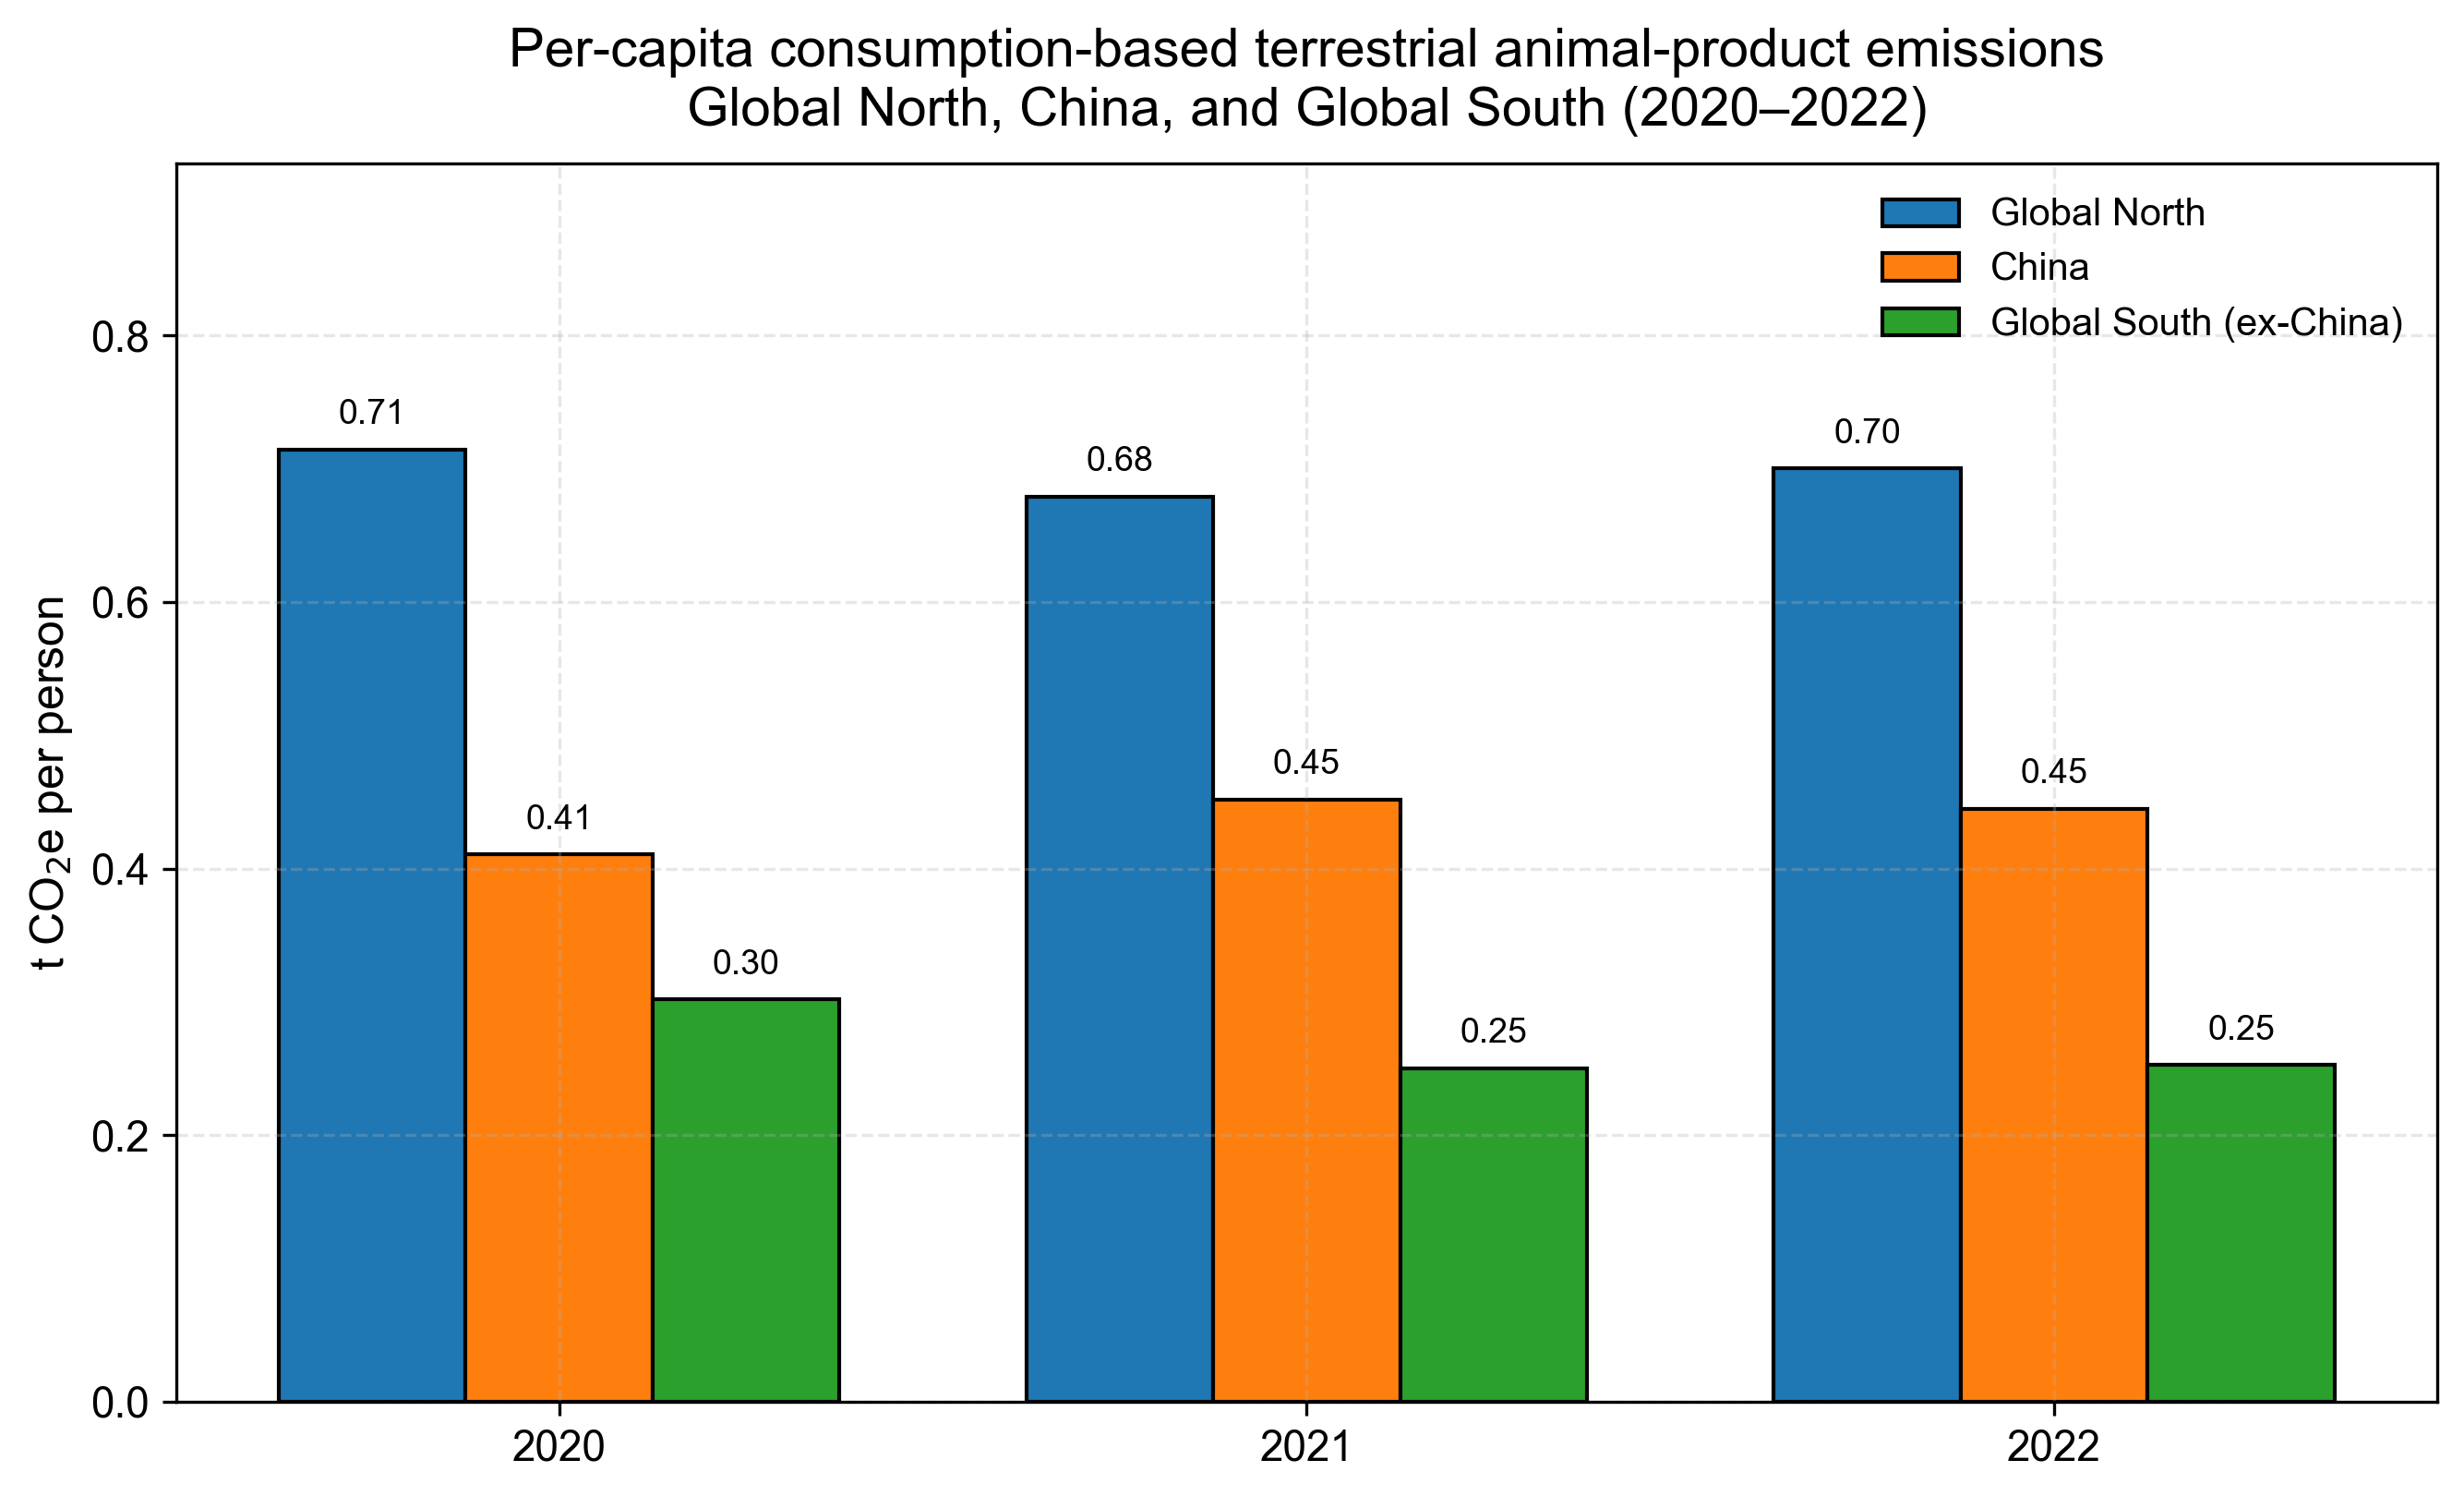

In [10]:

fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(YEARS))
bar_width = 0.25

for j, group in enumerate(GROUP_ORDER):
    sub = main_group[main_group["group"] == group].sort_values("year")

    ax.bar(
        x + (j - 1) * bar_width,
        sub["per_capita_tCO2e"],
        width=bar_width,
        label=GROUP_LABELS[group],
        edgecolor="black"
    )

ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in YEARS])
ax.set_ylabel("t CO$_2$e per person")
ax.set_title(
    "Per-capita consumption-based terrestrial animal-product emissions\n"
    "Global North, China, and Global South (2020–2022)"
)

ax.legend()
ymax = main_group["per_capita_tCO2e"].max()

for container in ax.containers:
    for rect in container:
        h = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width()/2,
            h + 0.02*ymax,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_ylim(0, ymax * 1.30)
plt.tight_layout()

fig.savefig(FIG_DIR / "figure4_revised_percap_terrestrial_animal_products.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "figure4_revised_percap_terrestrial_animal_products.png", bbox_inches="tight")
plt.show()


## 9. Population context used for manuscript interpretation

In [11]:

main_country = country_results[country_results["scope"] == main_scope].copy()

population_context = (
    main_country
    .groupby(["year", "group", "group_label"], as_index=False)
    .agg(
        population=("population", "sum"),
        total_tCO2e=("total_tCO2e", "sum")
    )
)

population_context["per_capita_tCO2e"] = (
    population_context["total_tCO2e"] / population_context["population"]
)

population_context["group"] = pd.Categorical(
    population_context["group"],
    categories=GROUP_ORDER,
    ordered=True
)

population_context = population_context.sort_values(["year", "group"])

population_context.to_csv(
    OUT_DIR / "population_context_group_totals.csv",
    index=False
)

display(population_context)


,year,group,group_label,population,total_tCO2e,per_capita_tCO2e
1,2020,GN,Global North,1.124546e+09,8.035842e+08,0.714585
0,2020,CN,China,1.411100e+09,5.794110e+08,0.410609
2,2020,GS,Global South (ex-China),2.218700e+09,6.693781e+08,0.301698
4,2021,GN,Global North,1.124159e+09,7.633847e+08,0.679072
3,2021,CN,China,1.412360e+09,6.379730e+08,0.451707
5,2021,GS,Global South (ex-China),2.234410e+09,5.591125e+08,0.250228
7,2022,GN,Global North,1.128571e+09,7.901518e+08,0.700135
6,2022,CN,China,1.412175e+09,6.285158e+08,0.445069
8,2022,GS,Global South (ex-China),2.249789e+09,5.683016e+08,0.252602


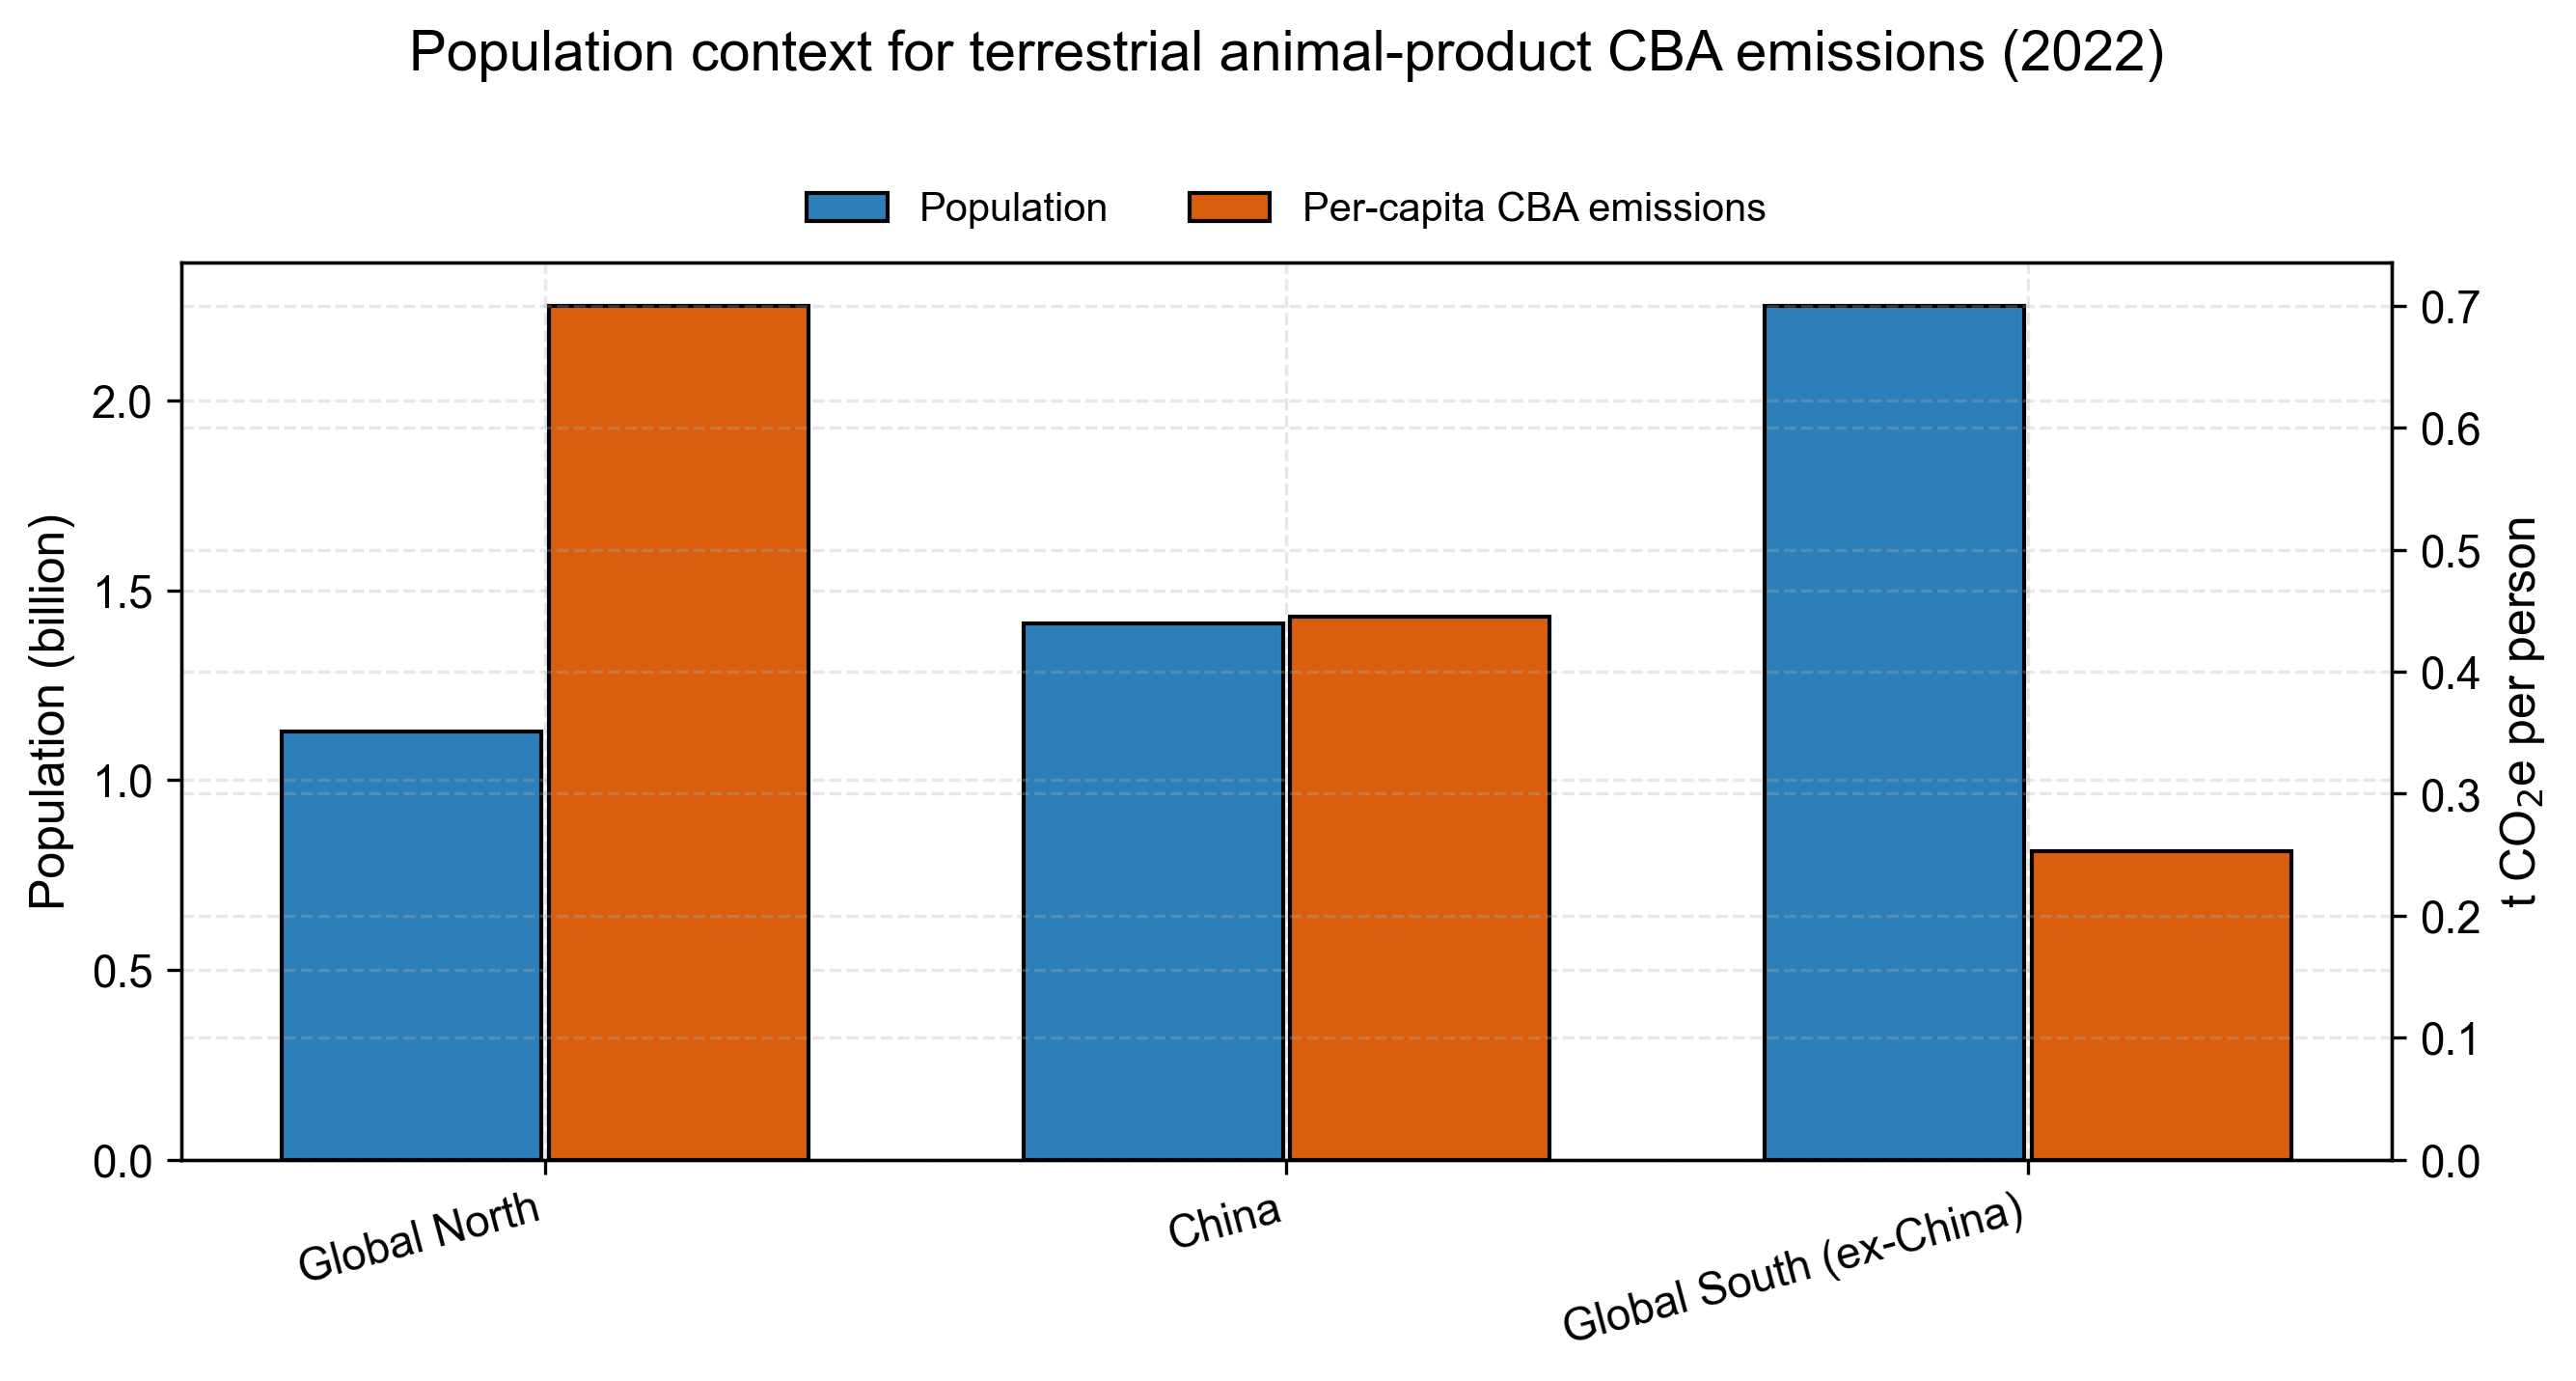

In [12]:
MAIN_COLOR = "#2c7fb8"      # total/population
SECONDARY_COLOR = "#d95f0e"  # per-capita

fig, ax1 = plt.subplots(figsize=(9, 5.8))

latest_year = max(YEARS)
latest_pop = population_context[population_context["year"] == latest_year].copy()
latest_pop = latest_pop.sort_values("group")

x = np.arange(len(latest_pop))

ax1.bar(
    x - 0.18,
    latest_pop["population"] / 1e9,
    width=0.35,
    label="Population",
    edgecolor="black",
    color=MAIN_COLOR
)

ax2 = ax1.twinx()

ax2.bar(
    x + 0.18,
    latest_pop["per_capita_tCO2e"],
    width=0.35,
    label="Per-capita CBA emissions",
    edgecolor="black",
    color=SECONDARY_COLOR
)

ax1.set_xticks(x)
ax1.set_xticklabels(latest_pop["group_label"], rotation=15, ha="right")

ax1.set_ylabel("Population (billion)")
ax2.set_ylabel("t CO$_2$e per person")

ax1.set_title(
    f"Population context for terrestrial animal-product CBA emissions ({latest_year})",
    pad=48
)

# Combine legends
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

# Move legend higher
ax1.legend(
    h1 + h2,
    l1 + l2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=2,
    frameon=False
)

# Reserve additional top space
plt.tight_layout(rect=[0, 0, 1, 0.84])

fig.savefig(FIG_DIR / "figure4_population_context_latest_year.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "figure4_population_context_latest_year.png", bbox_inches="tight")
plt.show()

## 10. Country-level top contributors used for manuscript interpretation

In [13]:

latest_country = main_country[main_country["year"] == latest_year].copy()

latest_country["group"] = pd.Categorical(
    latest_country["group"],
    categories=GROUP_ORDER,
    ordered=True
)

latest_country = latest_country.sort_values("total_tCO2e", ascending=False)

top10_total = latest_country.head(10).copy()
top10_total.to_csv(
    OUT_DIR / f"top10_country_total_emissions_{latest_year}.csv",
    index=False
)

display(top10_total[[
    "country", "region", "group_label", "total_tCO2e",
    "per_capita_tCO2e", "population", "share_of_scope_total_percent"
]])


,country,region,group_label,total_tCO2e,per_capita_tCO2e,population,share_of_scope_total_percent
265,China,CN,China,6.285158e+08,0.445069,1.412175e+09,31.631885
299,United States,US,Global North,3.253851e+08,0.974156,3.340173e+08,16.375951
262,Brazil,BR,Global South (ex-China),2.236313e+08,1.063359,2.103064e+08,11.254894
280,India,IN,Global South (ex-China),1.857986e+08,0.130346,1.425423e+09,9.350855
278,Indonesia,ID,Global South (ex-China),6.280404e+07,0.225241,2.788305e+08,3.160796
268,Germany,DE,Global North,5.805128e+07,0.692753,8.379798e+07,2.921599
294,Russian Federation,RU,Global South (ex-China),5.222329e+07,0.362066,1.442369e+08,2.628289
273,France,FR,Global North,5.154843e+07,0.757341,6.806502e+07,2.594325
263,Canada,CA,Global North,3.906376e+07,1.003283,3.893593e+07,1.965997
274,United Kingdom,GB,Global North,3.863864e+07,0.571544,6.760400e+07,1.944602


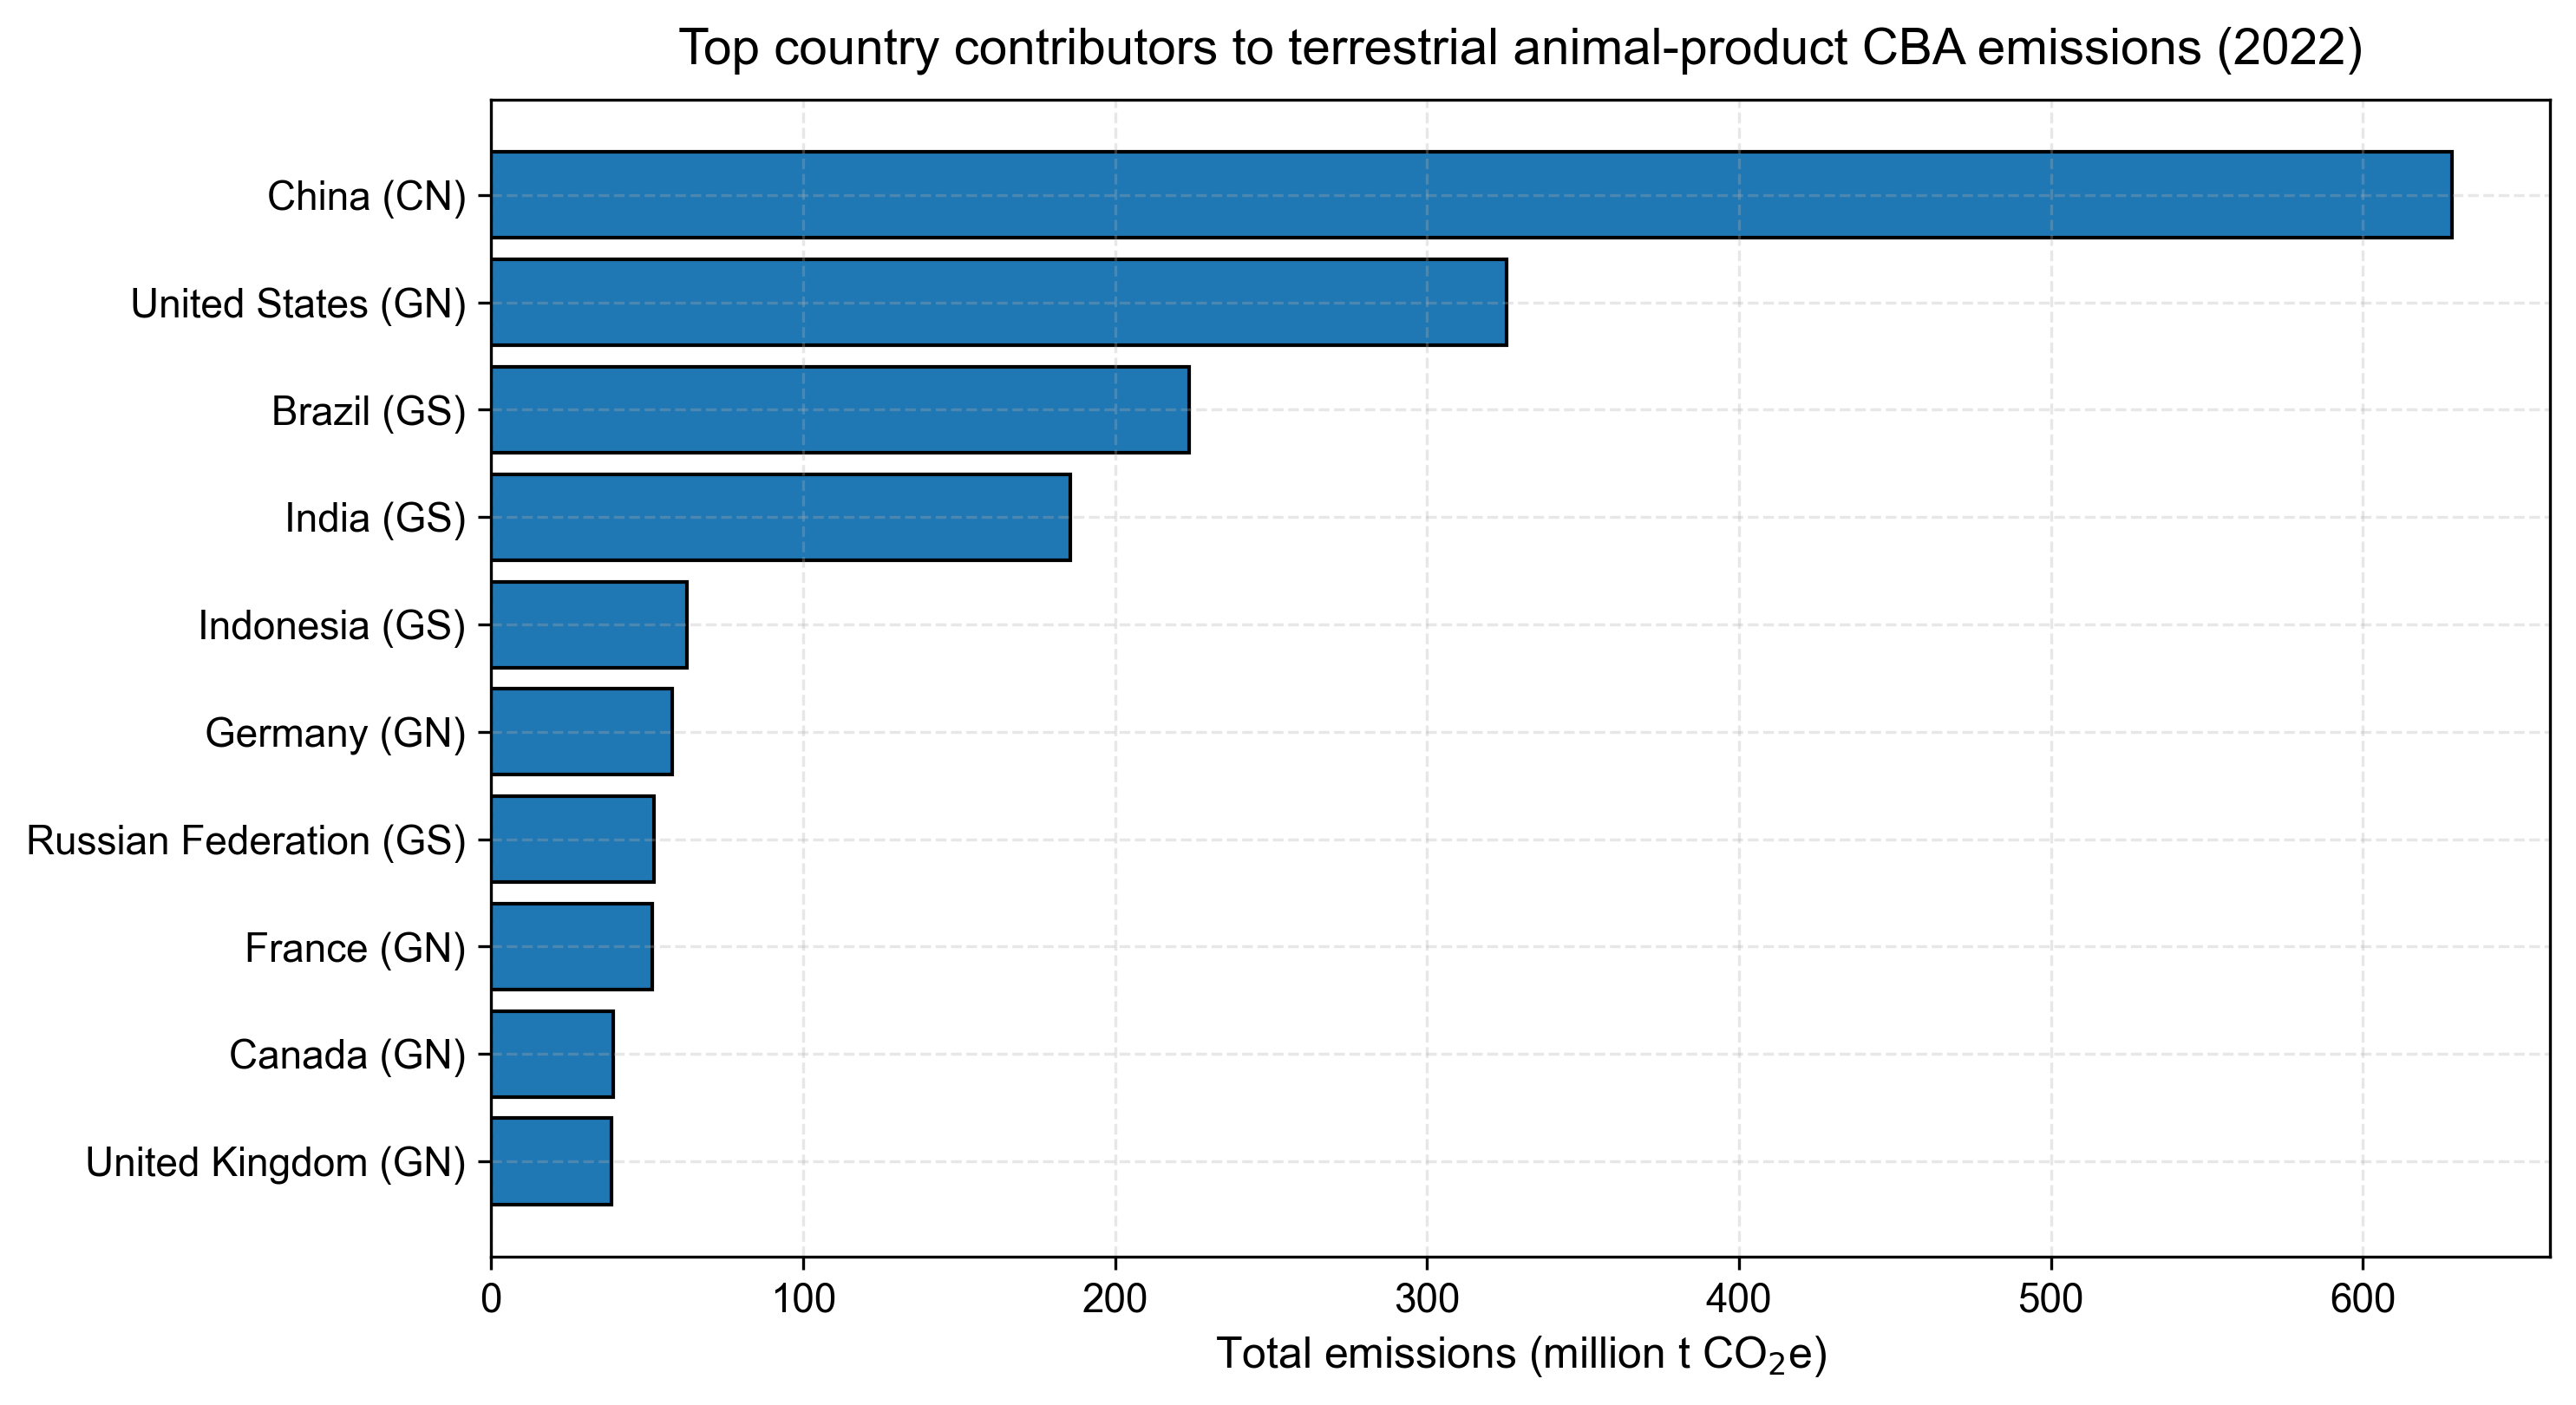

In [14]:

fig, ax = plt.subplots(figsize=(10, 5.5))

plot_df = top10_total.sort_values("total_tCO2e")
labels = plot_df["country"] + " (" + plot_df["group"].astype(str) + ")"

ax.barh(
    labels,
    plot_df["total_tCO2e"] / 1e6,
    edgecolor="black"
)

ax.set_xlabel("Total emissions (million t CO$_2$e)")
ax.set_title(
    f"Top country contributors to terrestrial animal-product CBA emissions ({latest_year})"
)

plt.tight_layout()

fig.savefig(FIG_DIR / f"top10_country_total_emissions_{latest_year}.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / f"top10_country_total_emissions_{latest_year}.png", bbox_inches="tight")
plt.show()


In [15]:

group_extremes = []

for group in GROUP_ORDER:
    sub = latest_country[latest_country["group"] == group].copy()

    if sub.empty:
        continue

    top3 = sub.sort_values("total_tCO2e", ascending=False).head(3).copy()
    top3["rank_type"] = "top3_total_emissions"

    low3 = sub.sort_values("total_tCO2e", ascending=True).head(3).copy()
    low3["rank_type"] = "lowest3_total_emissions"

    group_extremes.append(pd.concat([top3, low3], ignore_index=True))

group_extremes_df = pd.concat(group_extremes, ignore_index=True)

group_extremes_df.to_csv(
    OUT_DIR / f"group_top_low_country_contributors_{latest_year}.csv",
    index=False
)

display(group_extremes_df[[
    "group_label", "rank_type", "country", "region",
    "total_tCO2e", "share_of_scope_total_percent",
    "per_capita_tCO2e", "population"
]])


,group_label,rank_type,country,region,total_tCO2e,share_of_scope_total_percent,per_capita_tCO2e,population
0,Global North,top3_total_emissions,United States,US,3.253851e+08,16.375951,0.974156,3.340173e+08
1,Global North,top3_total_emissions,Germany,DE,5.805128e+07,2.921599,0.692753,8.379798e+07
2,Global North,top3_total_emissions,France,FR,5.154843e+07,2.594325,0.757341,6.806502e+07
3,Global North,lowest3_total_emissions,Malta,MT,2.752921e+05,0.013855,0.518331,5.311130e+05
4,Global North,lowest3_total_emissions,Estonia,EE,3.978351e+05,0.020022,0.294946,1.348840e+06
5,Global North,lowest3_total_emissions,Luxembourg,LU,4.435001e+05,0.022320,0.679066,6.531030e+05
6,China,top3_total_emissions,China,CN,6.285158e+08,31.631885,0.445069,1.412175e+09
7,China,lowest3_total_emissions,China,CN,6.285158e+08,31.631885,0.445069,1.412175e+09
8,Global South (ex-China),top3_total_emissions,Brazil,BR,2.236313e+08,11.254894,1.063359,2.103064e+08
9,Global South (ex-China),top3_total_emissions,India,IN,1.857986e+08,9.350855,0.130346,1.425423e+09


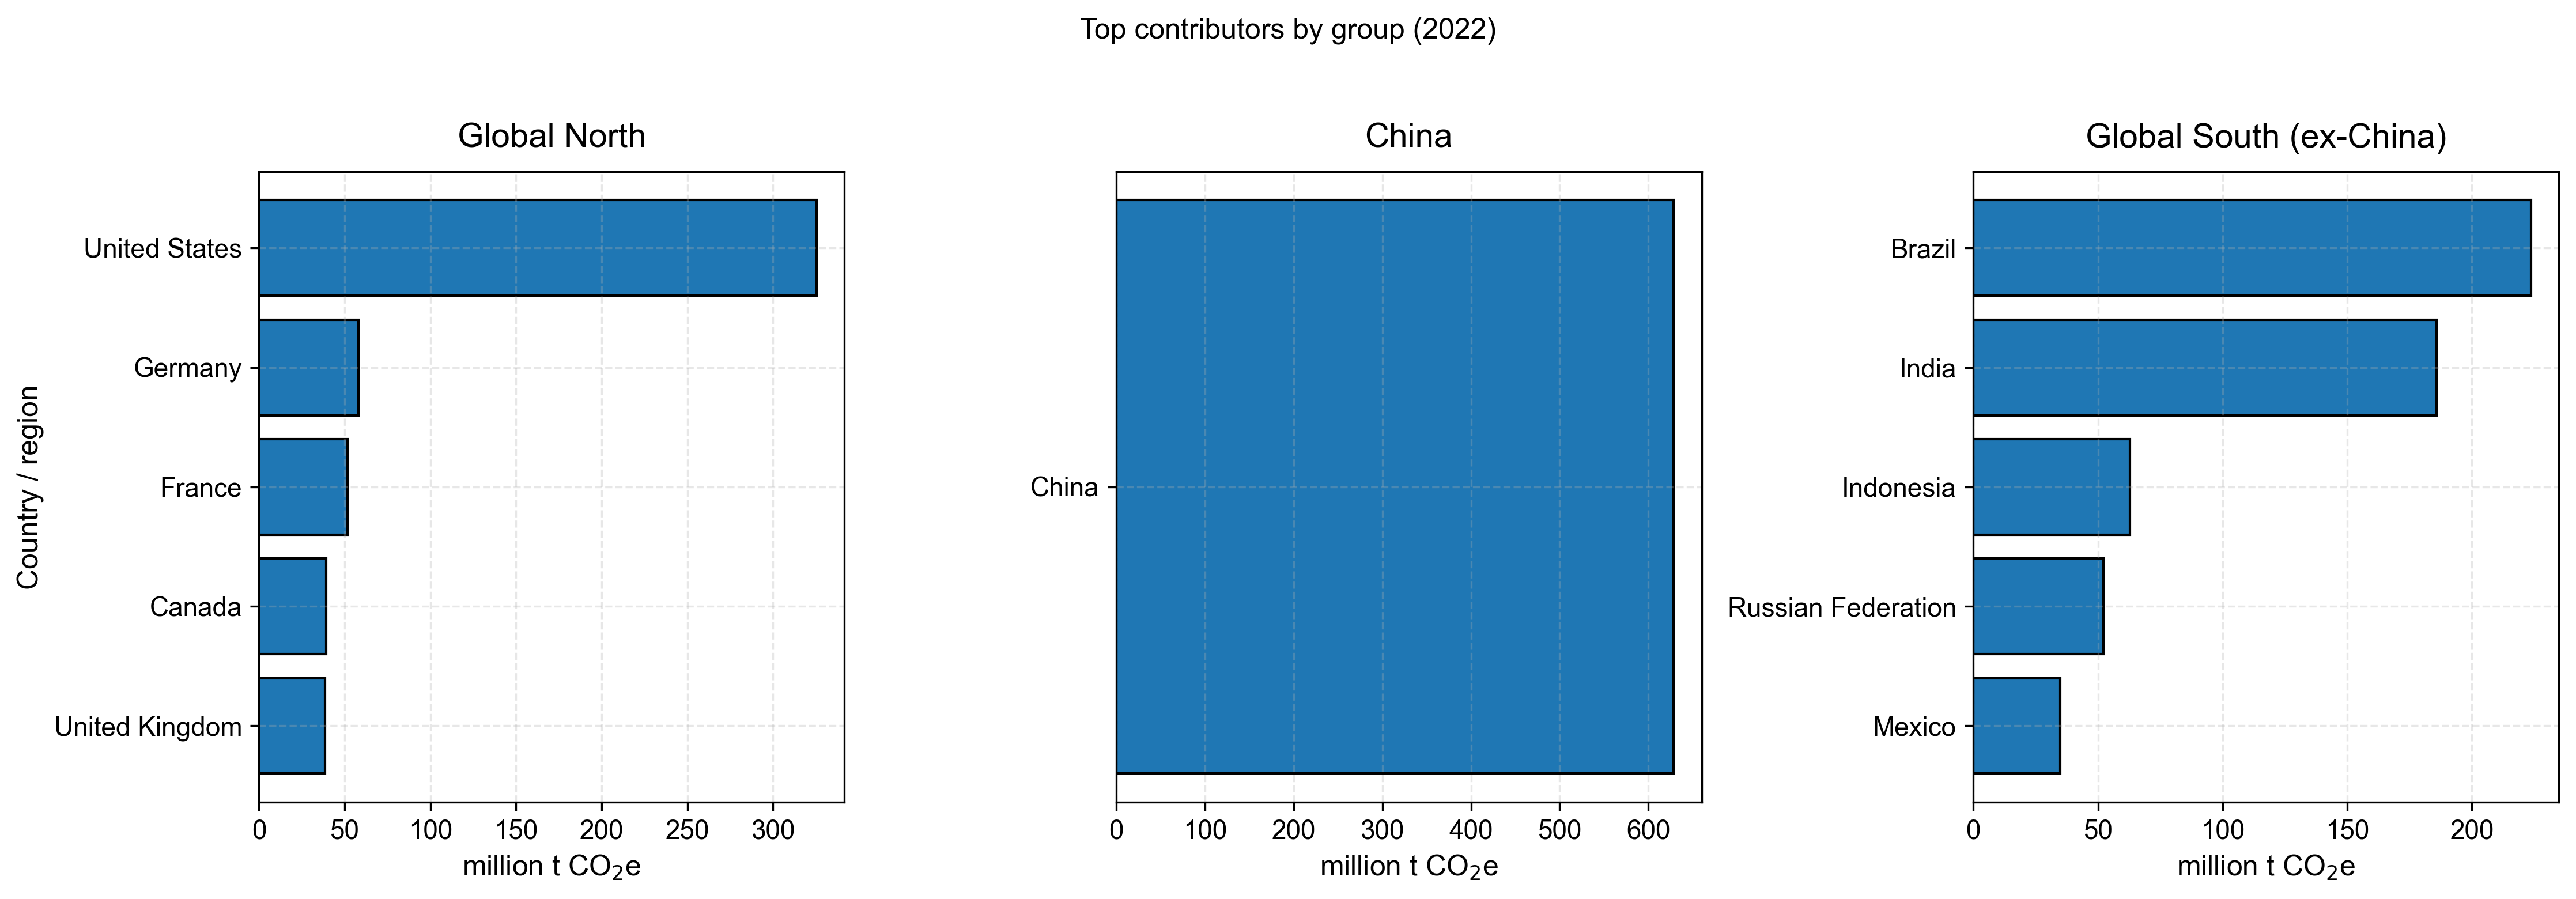

In [16]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=False)

for ax, group in zip(axes, GROUP_ORDER):
    sub = latest_country[latest_country["group"] == group].sort_values("total_tCO2e", ascending=False).head(5)
    sub = sub.sort_values("total_tCO2e")
    labels = sub["country"]

    ax.barh(labels, sub["total_tCO2e"] / 1e6, edgecolor="black")
    ax.set_title(GROUP_LABELS[group])
    ax.set_xlabel("million t CO$_2$e")

axes[0].set_ylabel("Country / region")
fig.suptitle(f"Top contributors by group ({latest_year})", y=1.03)

plt.tight_layout()

fig.savefig(FIG_DIR / f"top5_country_contributors_by_group_{latest_year}.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / f"top5_country_contributors_by_group_{latest_year}.png", bbox_inches="tight")
plt.show()



## 11. Total vs per-capita comparison

This plot helps clarify that total emissions are influenced by population size, while per-capita emissions reflect intensity of consumption-based responsibility.


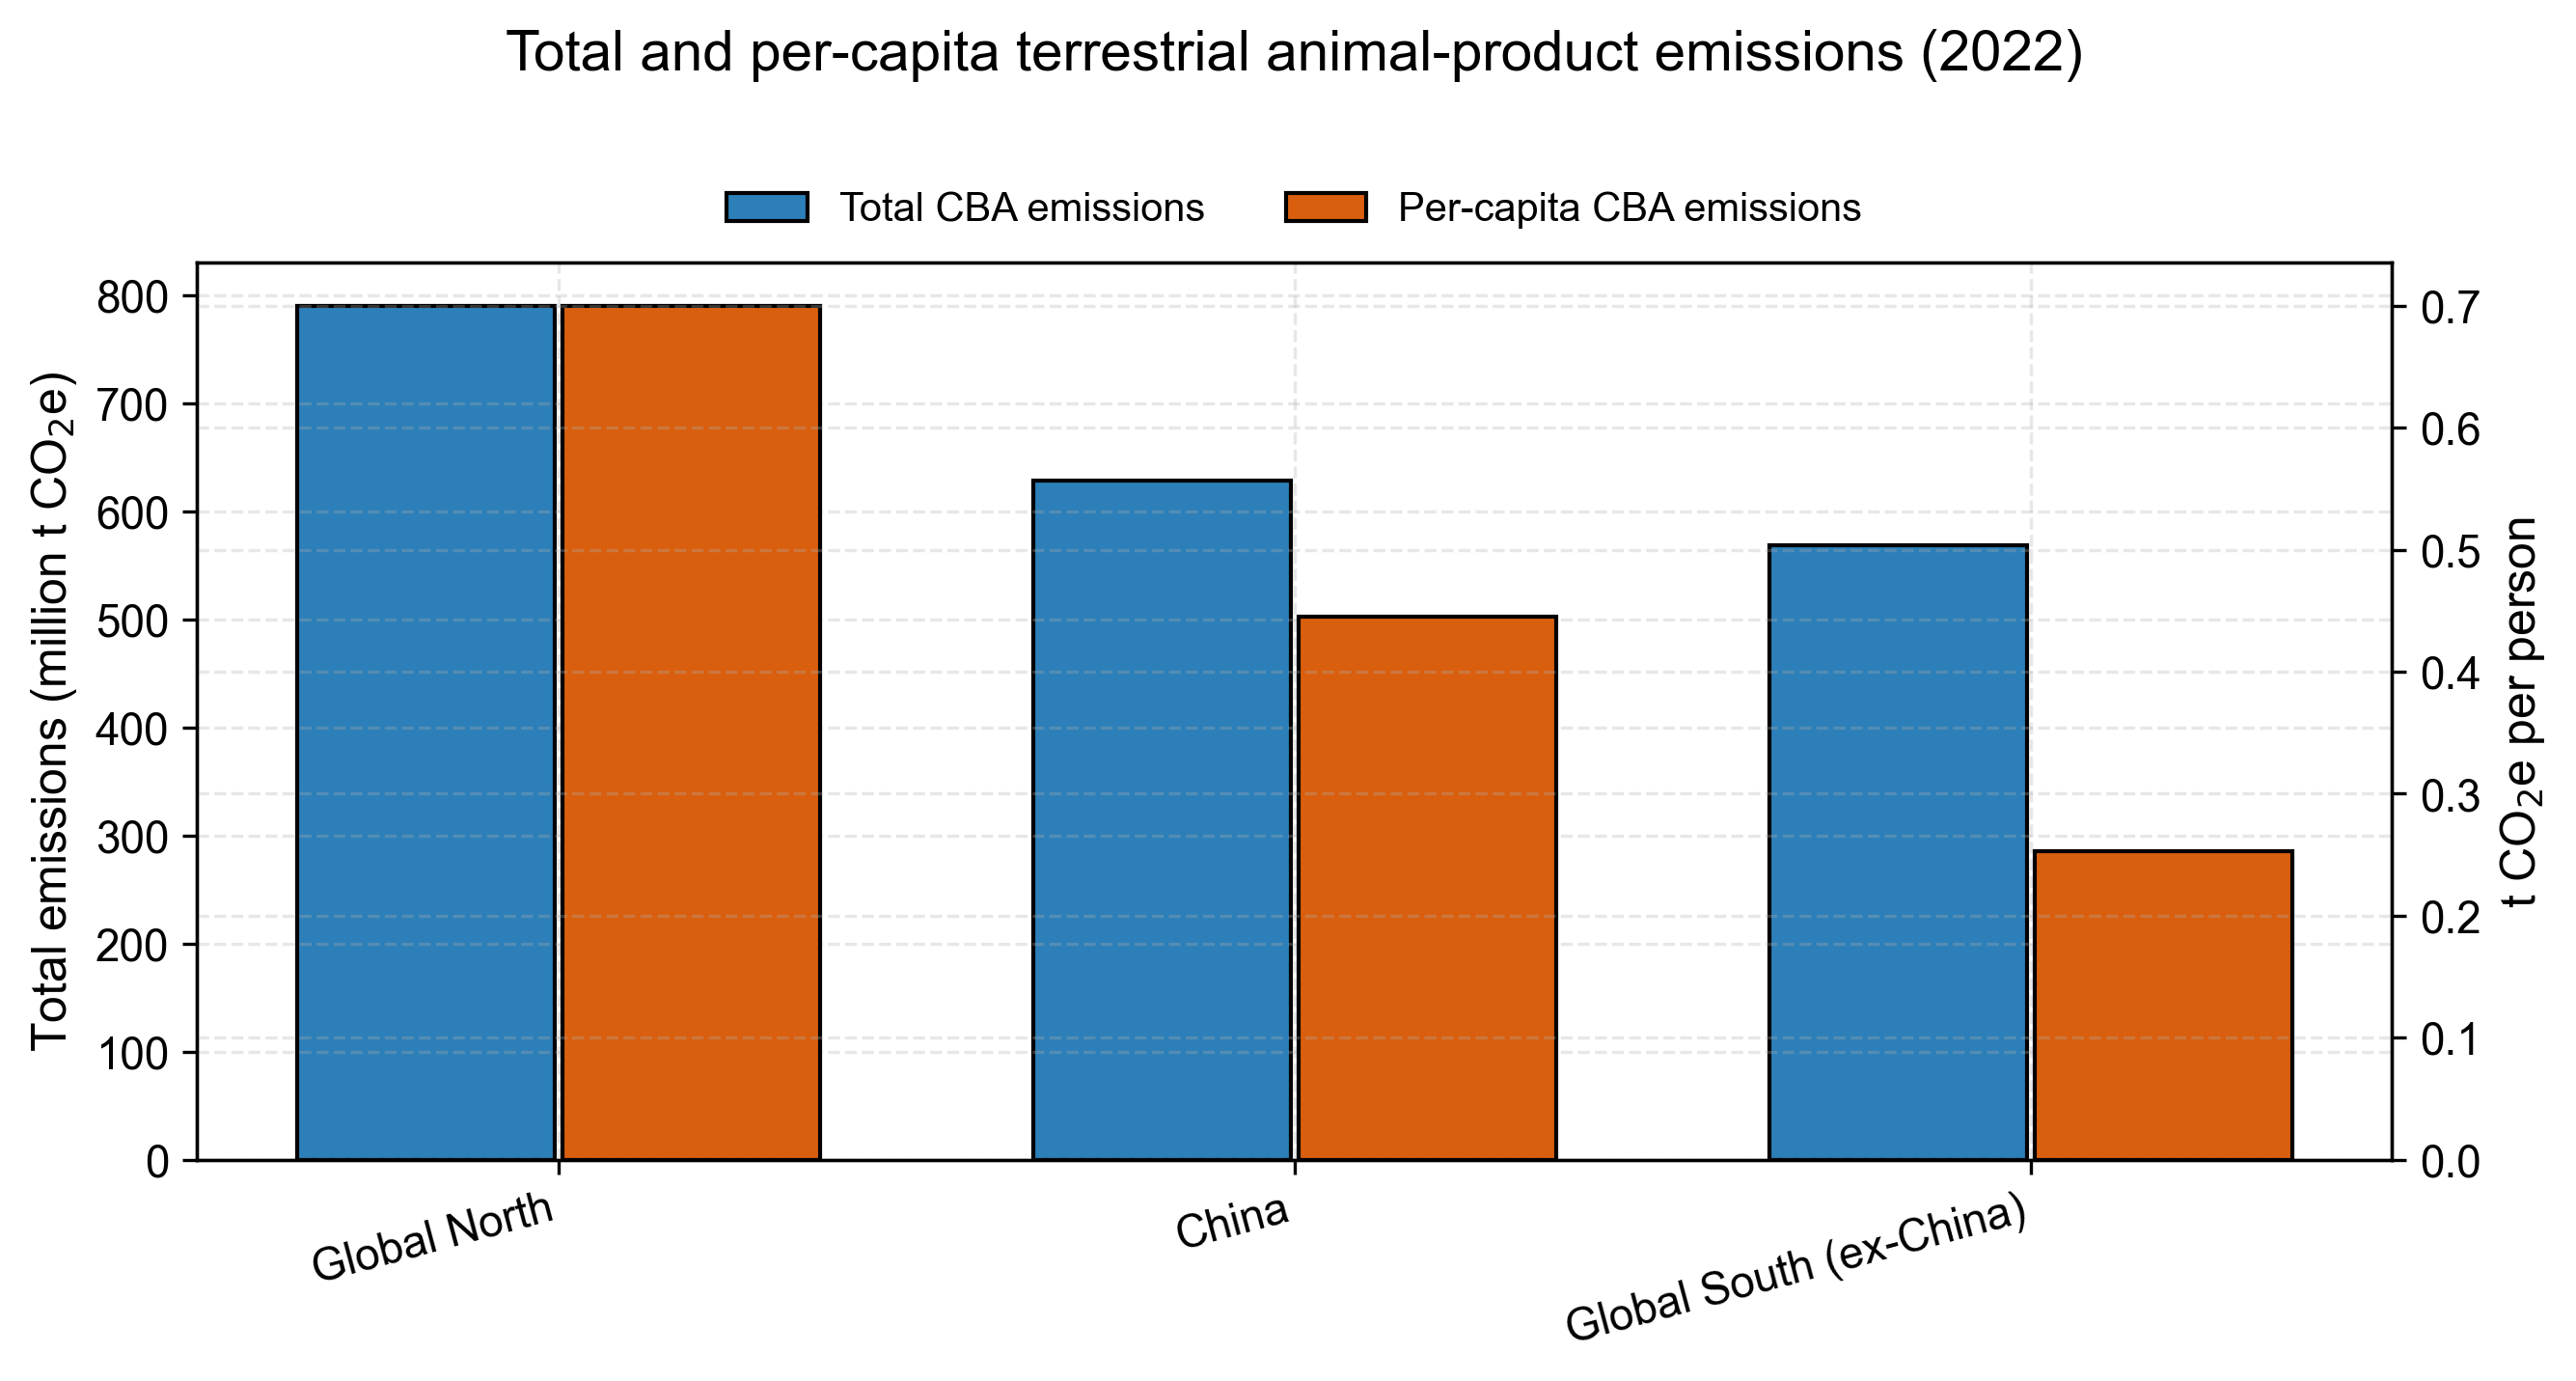

In [17]:
MAIN_COLOR = "#2c7fb8"      # total/population
SECONDARY_COLOR = "#d95f0e"  # per-capita


fig, ax1 = plt.subplots(figsize=(9, 5.8))

latest_group = main_group[main_group["year"] == latest_year].copy()
latest_group = latest_group.sort_values("group")

x = np.arange(len(latest_group))

# Total emissions bars
ax1.bar(
    x - 0.18,
    latest_group["total_tCO2e"] / 1e6,
    width=0.35,
    label="Total CBA emissions",
    edgecolor="black",
    color=MAIN_COLOR
)

# Secondary axis
ax2 = ax1.twinx()

# Per-capita bars
ax2.bar(
    x + 0.18,
    latest_group["per_capita_tCO2e"],
    width=0.35,
    label="Per-capita CBA emissions",
    edgecolor="black",
    color=SECONDARY_COLOR
)

# X labels
ax1.set_xticks(x)
ax1.set_xticklabels(
    latest_group["group_label"],
    rotation=15,
    ha="right"
)

# Axis labels
ax1.set_ylabel("Total emissions (million t CO$_2$e)")
ax2.set_ylabel("t CO$_2$e per person")

# Title with extra spacing
ax1.set_title(
    f"Total and per-capita terrestrial animal-product emissions ({latest_year})",
    pad=48
)

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(
    h1 + h2,
    l1 + l2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=2,
    frameon=False
)

# Extra top margin
plt.tight_layout(rect=[0, 0, 1, 0.84])

# Save
fig.savefig(
    FIG_DIR / f"total_vs_percap_group_{latest_year}.pdf",
    bbox_inches="tight"
)

fig.savefig(
    FIG_DIR / f"total_vs_percap_group_{latest_year}.png",
    bbox_inches="tight"
)

plt.show()


## 12. Sector-boundary sensitivity

This plot compares:
- main terrestrial animal-product scope;
- core livestock/meat/dairy scope;
- broader comparison scope including fisheries/fish products.


In [18]:

sensitivity = group_results.copy()

sensitivity["group"] = pd.Categorical(
    sensitivity["group"],
    categories=GROUP_ORDER,
    ordered=True
)

sensitivity.to_csv(
    OUT_DIR / "sector_scope_sensitivity_group_results.csv",
    index=False
)

display(sensitivity.head())


,scope,year,group,group_label,total_tCO2e,population,per_capita_tCO2e,share_of_scope_total_percent
0,terrestrial_animal_products,2020,CN,China,5.794110e+08,1.411100e+09,0.410609,28.231268
1,terrestrial_animal_products,2020,GN,Global North,8.035842e+08,1.124546e+09,0.714585,39.153900
2,terrestrial_animal_products,2020,GS,Global South (ex-China),6.693781e+08,2.218700e+09,0.301698,32.614832
3,core_livestock_meat_dairy,2020,CN,China,5.715966e+08,1.411100e+09,0.405072,28.145221
4,core_livestock_meat_dairy,2020,GN,Global North,7.926317e+08,1.124546e+09,0.704846,39.028911


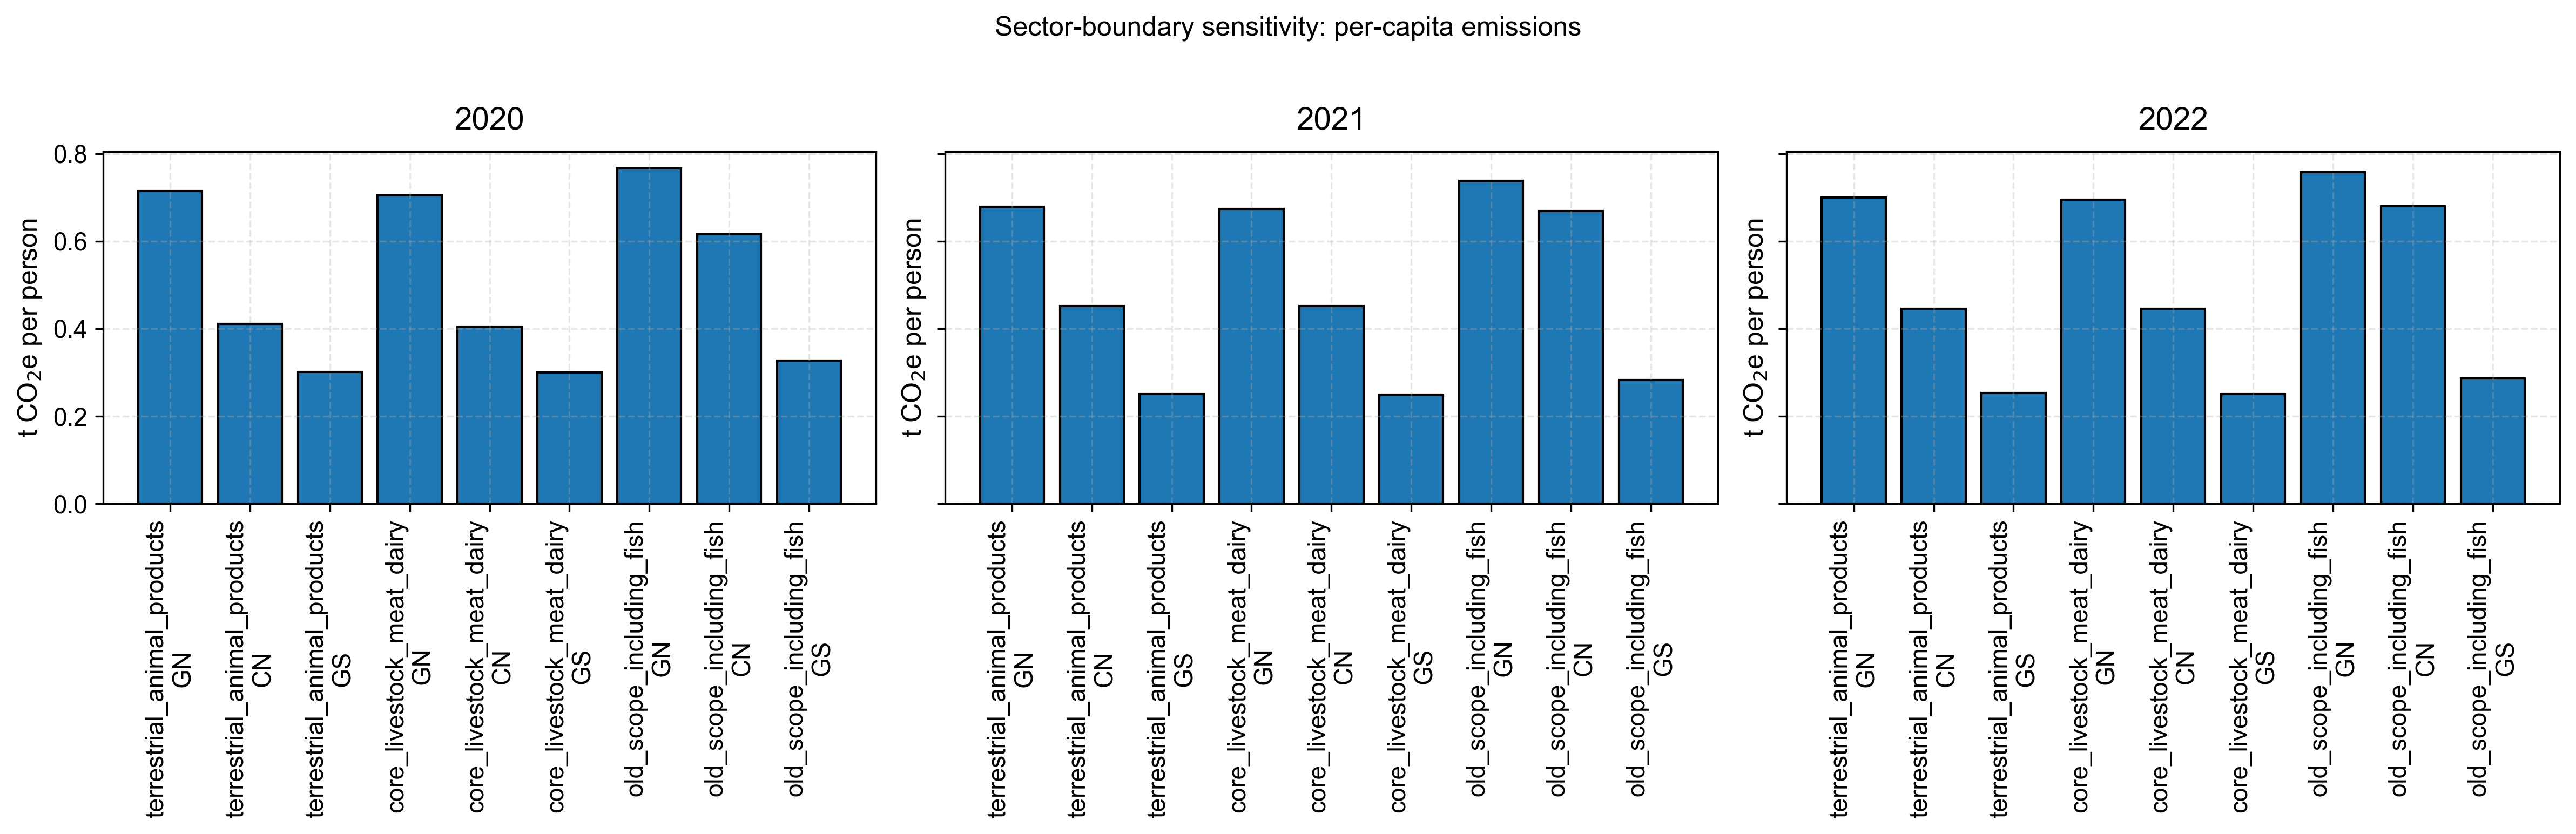

In [19]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, year in zip(axes, YEARS):
    sub = sensitivity[sensitivity["year"] == year].copy()
    sub = sub.sort_values(["scope", "group"])

    labels = []
    values = []

    for scope in SECTOR_SCOPES:
        for group in GROUP_ORDER:
            val = sub.loc[
                (sub["scope"] == scope) & (sub["group"] == group),
                "per_capita_tCO2e"
            ]
            labels.append(f"{scope}\n{group}")
            values.append(float(val.values[0]) if len(val) else np.nan)

    ax.bar(range(len(values)), values, edgecolor="black")
    ax.set_title(str(year))
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_ylabel("t CO$_2$e per person")

fig.suptitle("Sector-boundary sensitivity: per-capita emissions", y=1.02)

plt.tight_layout()

fig.savefig(FIG_DIR / "sector_boundary_sensitivity_percap.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "sector_boundary_sensitivity_percap.png", bbox_inches="tight")
plt.show()


## 13. Country-level scatter: population, total emissions, and per-capita emissions

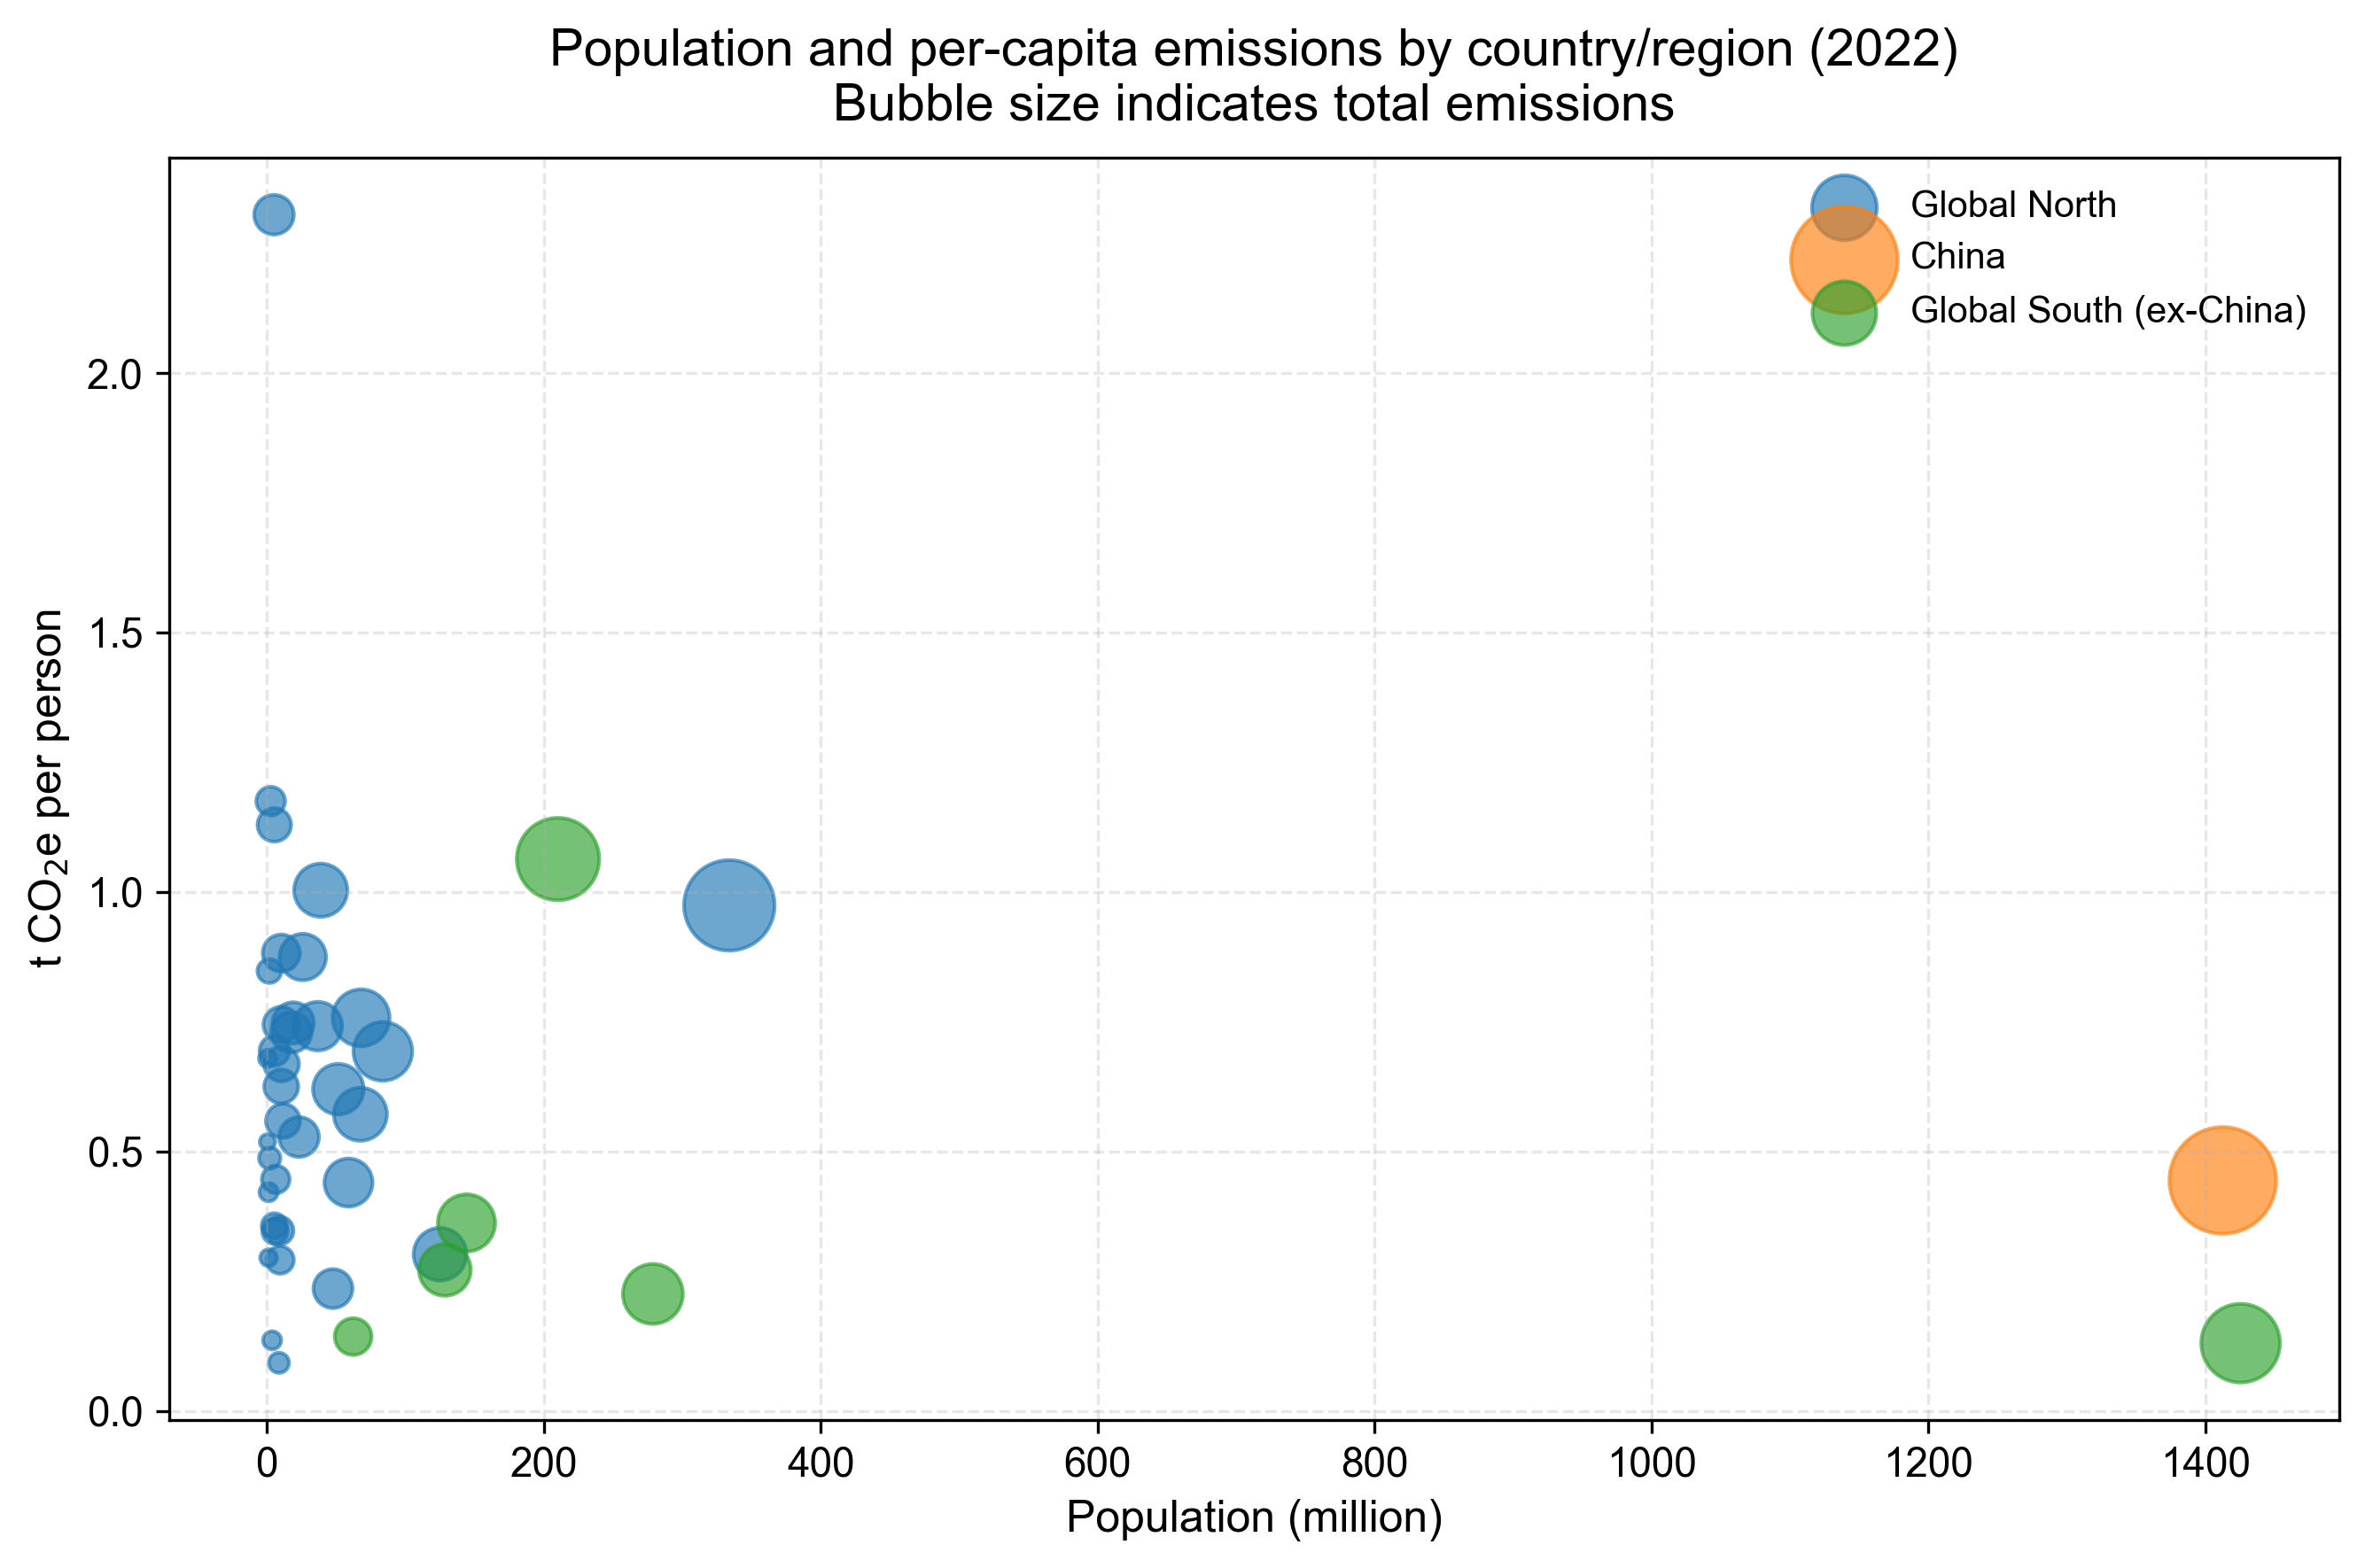

In [20]:

scatter_df = latest_country.copy()

fig, ax = plt.subplots(figsize=(9, 6))

for group in GROUP_ORDER:
    sub = scatter_df[scatter_df["group"] == group]

    sizes = np.sqrt(sub["total_tCO2e"].clip(lower=0)) / 30
    sizes = sizes.clip(lower=10, upper=900)

    ax.scatter(
        sub["population"] / 1e6,
        sub["per_capita_tCO2e"],
        s=sizes,
        alpha=0.65,
        label=GROUP_LABELS[group]
    )

ax.set_xlabel("Population (million)")
ax.set_ylabel("t CO$_2$e per person")
ax.set_title(
    f"Population and per-capita emissions by country/region ({latest_year})\n"
    "Bubble size indicates total emissions"
)

ax.legend()
plt.tight_layout()

fig.savefig(FIG_DIR / f"country_population_percap_scatter_{latest_year}.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / f"country_population_percap_scatter_{latest_year}.png", bbox_inches="tight")
plt.show()


## 14. Final output inventory

In [22]:

print("Output tables written to:", OUT_DIR.resolve())
for p in sorted(OUT_DIR.glob("*")):
    print("-", p.name)

print("Figures written to:", FIG_DIR.resolve())
for p in sorted(FIG_DIR.glob("*")):
    print("-", p.name)


Output tables written to: /Users/ritukajaiswal/Desktop/Climate Change Book/Animal Farming Paper/plots/Final Plots for livestock emissions/Review report JCLP/github_ready_code_files/exiobase/outputs
- .gitkeep
- country_level_exiobase_cba_all_scopes.csv
- figure4_main_group_percap_terrestrial_animal_products.csv
- group_level_exiobase_cba_all_scopes.csv
- group_top_low_country_contributors_2022.csv
- population_context_group_totals.csv
- retained_sector_audit_all_scopes.csv
- sector_scope_sensitivity_group_results.csv
- top10_country_total_emissions_2022.csv
Figures written to: /Users/ritukajaiswal/Desktop/Climate Change Book/Animal Farming Paper/plots/Final Plots for livestock emissions/Review report JCLP/github_ready_code_files/exiobase/figures
- .gitkeep
- country_population_percap_scatter_2022.pdf
- country_population_percap_scatter_2022.png
- figure4_population_context_latest_year.pdf
- figure4_population_context_latest_year.png
- figure4_revised_percap_terrestrial_animal_products.

In [23]:
# ============================================================
# Calculate global percentage shares for top contributors
# ============================================================

# Total global emissions
global_total = latest_country["total_tCO2e"].sum()

# Copy dataframe
top10_percent = top10_total.copy()

# Global percentage share
top10_percent["global_share_percent"] = (
    top10_percent["total_tCO2e"] / global_total
) * 100

# Group totals (GN / GS / CN)
group_totals = (
    latest_country
    .groupby("group")["total_tCO2e"]
    .sum()
    .to_dict()
)

# Within-group percentage share
top10_percent["within_group_share_percent"] = (
    top10_percent.apply(
        lambda row:
        row["total_tCO2e"]
        / group_totals[row["group"]]
        * 100,
        axis=1
    )
)

# Convert to million tCO2e for readability
top10_percent["MtCO2e"] = (
    top10_percent["total_tCO2e"] / 1e6
)

# Sort descending
top10_percent = top10_percent.sort_values(
    "global_share_percent",
    ascending=False
)

# Display results
print(
    top10_percent[
        [
            "country",
            "group",
            "MtCO2e",
            "global_share_percent",
            "within_group_share_percent"
        ]
    ]
    .round(2)
)

                country group  MtCO2e  global_share_percent  \
265               China    CN  628.52                 31.63   
299       United States    GN  325.39                 16.38   
262              Brazil    GS  223.63                 11.25   
280               India    GS  185.80                  9.35   
278           Indonesia    GS   62.80                  3.16   
268             Germany    GN   58.05                  2.92   
294  Russian Federation    GS   52.22                  2.63   
273              France    GN   51.55                  2.59   
263              Canada    GN   39.06                  1.97   
274      United Kingdom    GN   38.64                  1.94   

     within_group_share_percent  
265                      100.00  
299                       41.18  
262                       39.35  
280                       32.69  
278                       11.05  
268                        7.35  
294                        9.19  
273                        6.52  


In [24]:
latest_country["global_share_percent"] = (
    latest_country["total_tCO2e"] / latest_country["total_tCO2e"].sum()
) * 100

print(latest_country["global_share_percent"].sum())

100.0
